In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs("usc-infolab/deepstategnn", filters = {'$and': [{'tags': {"$in": ["benchmark_GBA", "withMD"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None, "tr_drop_025", "tr_drop_050", "tr_drop_075"]}}]})


In [3]:


from tqdm import tqdm
def get_runs_with_filters(filters):
    api = wandb.Api()
    runs = api.runs("usc-infolab/deepstategnn", filters = filters)
    return runs



def extract_run_data(runs, access_metadata = True):
    summary_list, config_list, name_list = [], [], []

    model_name_list = []
    mask_name_list = []
    mask_iter_list = []
    dataset_list = []
    test_avg_mae_list = []
    test_available_sensors_avg_mae_list = []
    test_unavailable_sensors_avg_mae_list = []
    test_avg_rmse_list = []
    test_avg_mape_list = []
    val_loss_list = []
    epochs_list = []
    n_context_emb_list = []
    n_context_list = []
    n_hid_list = []
    static_prefilter_mode_list = []
    gcn_layers_list = []
    ablation_concat_queries_list = []
    dsn_div_weight_list = []
    dsn_div_margin_list = []
    dropout_list = []
    benchmark_inference_mean_time_list = []
    benchmark_inference_std_time_list = []

    state_list = []
    tag_list = []
    gpu_type_list = [] 
    train_time_per_epoch_list = []
    val_time_list = []



    for run in tqdm(runs):
        # .summary contains the output keys/values for metrics like accuracy.
        #  We call ._json_dict to omit large files
        summary_list.append(run.summary._json_dict)
        
        # .config contains the hyperparameters.
        #  We remove special values that start with _.
        config_list.append(
            {k: v for k,v in run.config.items()
            if not k.startswith('_')})

        # .name is the human-readable name of the run.
        name_list.append(run.name)

        model_name_list.append(run.config.get("model_name"))
        mask_name_list.append(run.config.get("mask_name"))
        mask_iter_list.append(run.config.get("mask_iter"))
        dataset_list.append(run.config.get("dataset"))
        static_prefilter_mode_list.append(run.config.get("static_prefilter_mode", None))
        n_context_emb_list.append(run.config.get("n_context_emb"))
        n_context_list.append(run.config.get("n_context"))
        n_hid_list.append(run.config.get("n_hid"))
        gcn_layers_list.append(run.config.get("gcn_layers"))
        ablation_concat_queries_list.append(run.config.get("adding_query_to_dsn"))
        dsn_div_weight_list.append(run.config.get("dsn_div_weight"))
        dsn_div_margin_list.append(run.config.get("dsn_div_margin"))
        dropout_list.append(run.config.get("dropout"))

        if access_metadata:
            gpu_type_list.append(run.metadata.get("gpu") if run.metadata is not None else None)
        else:
            gpu_type_list.append(None)
        test_avg_mae_list.append(run.summary.get("test/avg_mae"))
        test_avg_rmse_list.append(run.summary.get("test/avg_rmse"))
        test_avg_mape_list.append(run.summary.get("test/avg_mape"))
        train_time_per_epoch_list.append(run.summary.get("train/time_per_epoch"))
        benchmark_inference_mean_time_list.append(run.summary.get("benchmark/inference_time_mean"))
        benchmark_inference_std_time_list.append(run.summary.get("benchmark/inference_time_std"))
        val_time_list.append(run.summary.get("val/time"))
        epochs_list.append(run.summary.get("epoch", None))
        state_list.append(run.state)
        tag_list.append(run.tags)


        if "test/available_sensors/avg_mae" in run.summary:
            test_available_sensors_avg_mae_list.append(run.summary.get("test/available_sensors/avg_mae"))
        else:
            test_available_sensors_avg_mae_list.append(None)
        if "test/unavailable_sensors/avg_mae" in run.summary:
            test_unavailable_sensors_avg_mae_list.append(run.summary.get("test/unavailable_sensors/avg_mae"))
        else:
            test_unavailable_sensors_avg_mae_list.append(None)
        if 'val/loss' in run.history_keys['keys'] and False:

            df = run.history(samples=100, keys=["val/loss"], pandas=True, stream="default")

            val_loss_list.append(df['val/loss'].min())

        else:
            val_loss_list.append(None)

    runs_df = pd.DataFrame({
        "summary": summary_list,
        "config": config_list,
        "name": name_list
        })
    
    runs = pd.DataFrame(
        {
            "model_name": model_name_list,
            "mask_name": mask_name_list,
            "mask_iter": mask_iter_list,
            "dataset": dataset_list,
            "gpu_type": gpu_type_list,
            "n_context_emb": n_context_emb_list,
            "n_hid": n_hid_list,
            "static_prefilter_mode": static_prefilter_mode_list,
            "gcn_layers": gcn_layers_list,
            "ablation_concat_queries": ablation_concat_queries_list,
            "dsn_div_weight": dsn_div_weight_list,
            "dsn_div_margin": dsn_div_margin_list,
            "dropout": dropout_list,
            "n_context": n_context_list,    
            "test_avg_mae": test_avg_mae_list,
            "test_available_sensors_avg_mae": test_available_sensors_avg_mae_list,
            "test_unavailable_sensors_avg_mae": test_unavailable_sensors_avg_mae_list,
            "train_time_per_epoch": train_time_per_epoch_list,
            "benchmark_inference_mean_time": benchmark_inference_mean_time_list,
            "benchmark_inference_std_time": benchmark_inference_std_time_list,
            "test_avg_mape": test_avg_mape_list,
            "test_avg_rmse": test_avg_rmse_list,
            "name": name_list, 
            "epochs": epochs_list,
            "state": state_list,
            "tags": tag_list,
            "val_loss": val_loss_list,
            "val_time": val_time_list
        }
    )
    # check if the tag withMD is set in the list of tags
    runs["withMD"] = runs["tags"].apply(lambda x: "withMD" in x)
    runs["benchmark_GBA"] = runs["tags"].apply(lambda x: "benchmark_GBA" in x)
    runs["train_mask"] = runs["tags"].apply(lambda x: "train_mask" in x)


    # runs= runs[(runs["state"] == "finished") & (runs["withMD"] | runs["benchmark_GBA"] ) ]
    runs['withMD'] = runs['withMD'].astype(str)
    runs.loc[runs['mask_name'].isna(), 'mask_name'] = 'no_mask'
    
    return runs

In [4]:
runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["benchmark_GBA", "withMD"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None, "tr_drop_025", "tr_drop_050", "tr_drop_075"]}}]}), access_metadata = False)

100%|██████████| 373/373 [00:03<00:00, 98.96it/s] 


In [5]:
runs[runs["withMD"].astype(bool)].loc[:, 'mask_name'].str.startswith("tr_drop").sum()

263

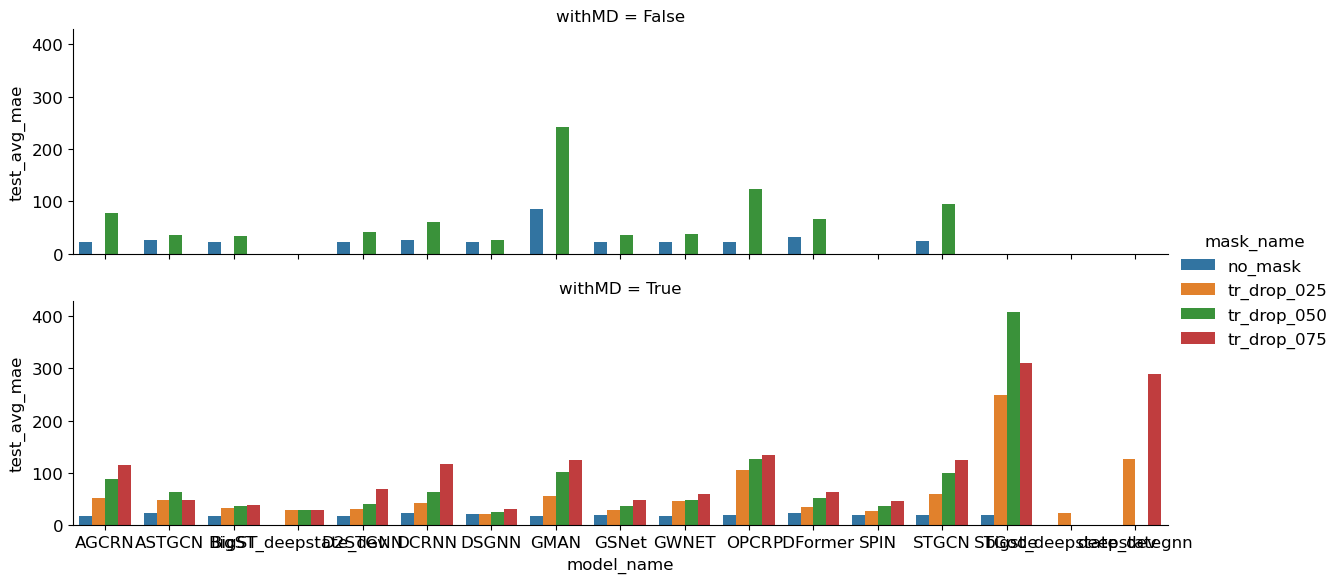

In [14]:
grouped_runs = runs.groupby(['model_name', 'mask_name', 'withMD']).mean()


# plot the test_avg_mae for each model_name and mask_name

import matplotlib.pyplot as plt
import seaborn as sns
# plt.figure(figsize=(100, 6))

# g = sns.FacetGrid(grouped_runs.reset_index(), col="withMD", hue='mask_name', aspect=5)
# # g.map(sns.barplot, 'model_name', 'test_avg_mae', hue='mask_name')
# g.map(sns.barplot, "model_name", "test_avg_mae")

sns.catplot(
    data=grouped_runs.reset_index(), x="model_name", y="test_avg_mae", row="withMD",
    kind="bar", height=3, aspect=4, hue="mask_name"

)



# g.add_legend()

# plt.title('Average Test MAE by Model and Mask Type')
# plt.ylabel('Average Test MAE')
# plt.xlabel('Model Name')
# plt.legend(title='Mask Name')
# plt.tight_layout()


In [15]:
runs[runs['withMD'] == 'True'][runs.model_name == 'DSGNN'].sort_values('mask_name')

/tmp/ipykernel_744345/3549842969.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  runs[runs['withMD'] == 'True'][runs.model_name == 'DSGNN'].sort_values('mask_name')


,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,n_hid,static_prefilter_mode,gcn_layers,ablation_concat_queries,...,test_avg_rmse,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,train_mask
29,DSGNN,no_mask,0.0,SD,None,64.0,64.0,static_dsn,2.0,True,...,34.132318,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 14:46,100.0,finished,[withMD],None,20.280985,True,False,False
39,DSGNN,no_mask,0.0,SD,None,64.0,64.0,static_dsn,2.0,True,...,34.132318,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 11:22,100.0,finished,[withMD],None,20.474454,True,False,False
33,DSGNN,no_mask,0.0,SD,None,64.0,64.0,static_dsn,2.0,True,...,33.879017,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 13:55,100.0,finished,[withMD],None,10.803917,True,False,False
44,DSGNN,no_mask,0.0,SD,None,64.0,64.0,static_dsn,2.0,True,...,33.776312,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 11:22,100.0,finished,[withMD],None,11.271893,True,False,False
37,DSGNN,no_mask,0.0,SD,None,64.0,64.0,static_dsn,2.0,True,...,34.132318,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 12:24,100.0,finished,[withMD],None,20.283139,True,False,False
45,DSGNN,tr_drop_025,0.0,SD,None,64.0,64.0,static_dsn,2.0,True,...,36.189495,DSGNN_SD_2019_DSGNN_tr_drop_025_0_2026-04-20 1...,100.0,finished,[withMD],None,9.365708,True,False,False
28,DSGNN,tr_drop_025,4.0,SD,None,64.0,64.0,static_dsn,2.0,True,...,37.358270,DSGNN_SD_2019_DSGNN_tr_drop_025_4_2026-04-20 1...,100.0,finished,[withMD],None,8.794108,True,False,False
40,DSGNN,tr_drop_025,1.0,SD,None,64.0,64.0,static_dsn,2.0,True,...,36.440879,DSGNN_SD_2019_DSGNN_tr_drop_025_1_2026-04-20 1...,100.0,finished,[withMD],None,16.140737,True,False,False
32,DSGNN,tr_drop_025,3.0,SD,None,64.0,64.0,static_dsn,2.0,True,...,36.636499,DSGNN_SD_2019_DSGNN_tr_drop_025_3_2026-04-20 1...,100.0,finished,[withMD],None,9.513373,True,False,False
36,DSGNN,tr_drop_025,2.0,SD,None,64.0,64.0,static_dsn,2.0,True,...,37.689895,DSGNN_SD_2019_DSGNN_tr_drop_025_2_2026-04-20 1...,100.0,finished,[withMD],None,9.420706,True,False,False


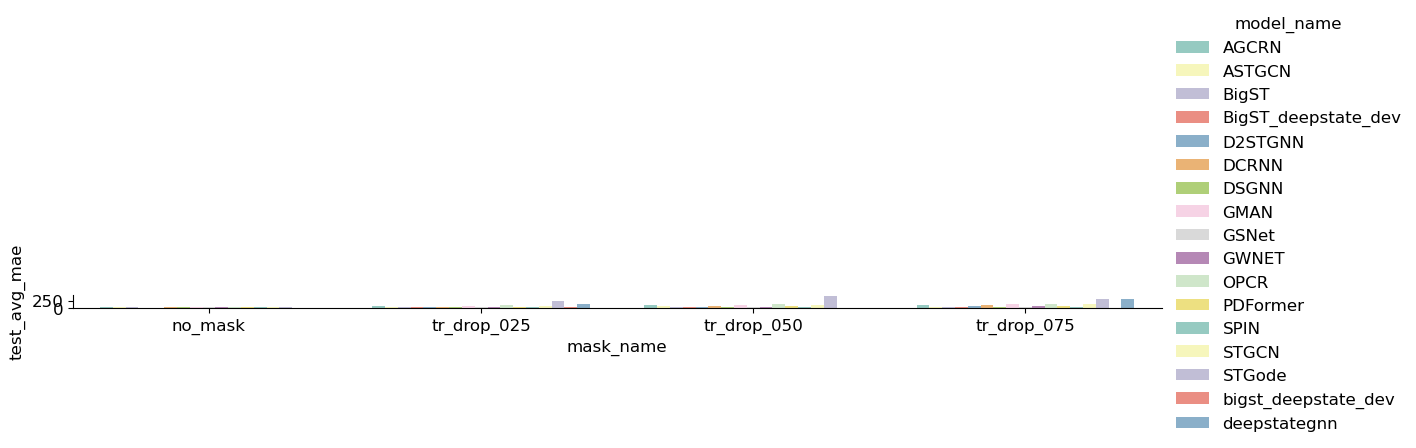

In [16]:
grouped_runs = runs[runs['withMD'] == 'True'].groupby(['model_name', 'mask_name', 'withMD']).mean()


# plot the test_avg_mae for each model_name and mask_name

import matplotlib.pyplot as plt
import seaborn as sns
# plt.figure(figsize=(100, 6))

# g = sns.FacetGrid(grouped_runs.reset_index(), col="withMD", hue='mask_name', aspect=5)
# # g.map(sns.barplot, 'model_name', 'test_avg_mae', hue='mask_name')
# g.map(sns.barplot, "model_name", "test_avg_mae")

sns.catplot(
    data=grouped_runs.reset_index(), x="mask_name", y="test_avg_mae",
    kind="bar", height=3, aspect=4, hue="model_name", palette = 'Set3'

)

In [17]:
grouped_runs

mask_iter  n_context_emb  n_hid  \
model_name          mask_name   withMD                                    
AGCRN               no_mask     True          0.0            NaN    NaN   
                    tr_drop_025 True          2.0            NaN    NaN   
                    tr_drop_050 True          2.0            NaN    NaN   
                    tr_drop_075 True          2.0            NaN    NaN   
ASTGCN              no_mask     True          0.0            NaN    NaN   
...                                           ...            ...    ...   
STGode              tr_drop_050 True          2.0            NaN    NaN   
                    tr_drop_075 True          2.0            NaN    NaN   
bigst_deepstate_dev tr_drop_025 True          0.0            NaN    NaN   
deepstategnn        tr_drop_025 True          1.0            NaN    NaN   
                    tr_drop_075 True          0.5            NaN    NaN   

                                        gcn_layers  dsn_div_weight  \
model_name          mask_name   withMD                               
AGCRN               no_mask     True           NaN             NaN   
                    tr_drop_025 True           NaN             NaN   
                    tr_drop_050 True           NaN             NaN   
                    tr_drop_075 True           NaN             NaN   
ASTGCN              no_mask     True           NaN             NaN   
...                                            ...             ...   
STGode              tr_drop_050 True           NaN             NaN   
                    tr_drop_075 True           NaN             NaN   
bigst_deepstate_dev tr_drop_025 True           NaN             NaN   
deepstategnn        tr_drop_025 True           NaN             NaN   
                    tr_drop_075 True           NaN             NaN   

                                        dsn_div_margin  dropout  n_context  \
model_name          mask_name   withMD                                       
AGCRN               no_mask     True               NaN      NaN        NaN   
                    tr_drop_025 True               NaN      NaN        NaN   
                    tr_drop_050 True               NaN      NaN        NaN   
                    tr_drop_075 True               NaN      NaN        NaN   
ASTGCN              no_mask     True               NaN      NaN        NaN   
...                                                ...      ...        ...   
STGode              tr_drop_050 True               NaN      NaN        NaN   
                    tr_drop_075 True               NaN      NaN        NaN   
bigst_deepstate_dev tr_drop_025 True               NaN      0.3        NaN   
deepstategnn        tr_drop_025 True               NaN      0.3        NaN   
                    tr_drop_075 True               NaN      0.3        NaN   

                                        test_avg_mae  \
model_name          mask_name   withMD                 
AGCRN               no_mask     True       18.131707   
                    tr_drop_025 True       52.525613   
                    tr_drop_050 True       87.584957   
                    tr_drop_075 True      116.045057   
ASTGCN              no_mask     True       24.417712   
...                                              ...   
STGode              tr_drop_050 True      408.194311   
                    tr_drop_075 True      311.052436   
bigst_deepstate_dev tr_drop_025 True       22.735325   
deepstategnn        tr_drop_025 True      127.509798   
                    tr_drop_075 True      288.893189   

                                        test_available_sensors_avg_mae  \
model_name          mask_name   withMD                                   
AGCRN               no_mask     True                               NaN   
                    tr_drop_025 True                               NaN   
                    tr_drop_050 True                               NaN   
                    tr_drop_075 True   

In [18]:
tmp = grouped_runs.reset_index()
# tmp = tmp[tmp.withMD]



In [19]:
tmp = tmp[~tmp.model_name.str.contains('deep')]

In [20]:
tmp[tmp.mask_name == 'no_mask'].loc[:, ['test_available_sensors_avg_mae']] = tmp[tmp.mask_name == 'no_mask'].loc[:, ['test_avg_mae']].values

/tmp/ipykernel_744345/3099442978.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tmp[tmp.mask_name == 'no_mask'].loc[:, ['test_available_sensors_avg_mae']] = tmp[tmp.mask_name == 'no_mask'].loc[:, ['test_avg_mae']].values


In [21]:
tmp[tmp.model_name == 'DSGNN']


,model_name,mask_name,withMD,mask_iter,n_context_emb,n_hid,gcn_layers,dsn_div_weight,dsn_div_margin,dropout,...,test_unavailable_sensors_avg_mae,train_time_per_epoch,benchmark_inference_mean_time,benchmark_inference_std_time,test_avg_mape,test_avg_rmse,epochs,val_time,benchmark_GBA,train_mask
23,DSGNN,no_mask,True,0.0,64.0,64.0,2.0,1.0,0.001,0.1,...,NaN,74.533302,NaN,NaN,0.143829,34.010457,100.0,16.622878,0.0,0.0
24,DSGNN,tr_drop_025,True,2.0,64.0,64.0,2.0,1.0,0.001,0.1,...,27.564835,43.558127,NaN,NaN,0.154541,36.863008,100.0,10.646926,0.0,0.0
25,DSGNN,tr_drop_050,True,2.0,64.0,64.0,2.0,1.0,0.001,0.1,...,29.009468,36.260638,NaN,NaN,0.178443,40.519387,100.0,8.507166,0.0,0.0
26,DSGNN,tr_drop_075,True,2.0,64.0,64.0,2.0,1.0,0.001,0.1,...,33.975311,24.584708,NaN,NaN,0.225896,49.276836,92.8,5.604621,0.0,0.0


In [22]:
pivoted_tmp_mae = tmp.pivot(index='mask_name', columns='model_name', values='test_avg_mae')
pivoted_tmp_av_mae = tmp.pivot(index='mask_name', columns='model_name', values='test_available_sensors_avg_mae')
pivoted_tmp_rmse = tmp.pivot(index='mask_name', columns='model_name', values='test_avg_rmse')
pivoted_tmp_mape = tmp.pivot(index='mask_name', columns='model_name', values='test_avg_mape')




In [40]:
[f'{x}%' for x in np.arange(4) *.25]

NameError: name 'np' is not defined

In [23]:
pivoted_tmp_mae = pivoted_tmp_mae.loc[['no_mask', 'tr_drop_025', 'tr_drop_050','tr_drop_075']]
pivoted_tmp_av_mae = pivoted_tmp_av_mae.loc[['no_mask', 'tr_drop_025', 'tr_drop_050','tr_drop_075']]
pivoted_tmp_rmse = pivoted_tmp_rmse.loc[['no_mask', 'tr_drop_025', 'tr_drop_050','tr_drop_075']]
pivoted_tmp_mape = pivoted_tmp_mape.loc[['no_mask', 'tr_drop_025', 'tr_drop_050','tr_drop_075']]

In [ ]:
pivoted_tmp_av_mae

model_name,AGCRN,ASTGCN,BigST,D2STGNN,DCRNN,DSGNN,GMAN,GSNet,GWNET,OPCR,PDFormer,SPIN,STGCN,STGode
mask_name,,,,,,,,,,,,,,
no_mask,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tr_drop_025,NaN,NaN,NaN,NaN,NaN,20.783448,NaN,24.293804,NaN,102.239037,34.829579,22.960667,NaN,NaN
tr_drop_050,NaN,NaN,NaN,NaN,NaN,20.712433,NaN,30.228826,NaN,124.811443,52.291862,29.254252,NaN,NaN
tr_drop_075,NaN,NaN,NaN,NaN,NaN,21.163795,NaN,39.183777,NaN,129.045856,61.397794,33.894328,NaN,NaN


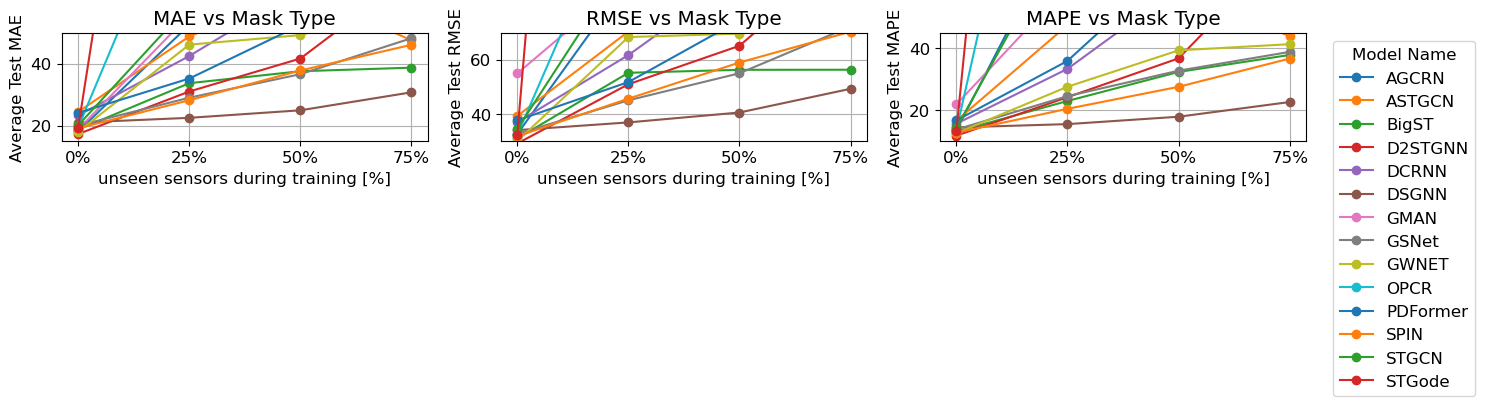

In [43]:
# Do a line plot instead with at the x axis being the mask_names

fig = plt.figure(figsize=(15,3))
ax = fig.add_subplot(1,3,1)



pivoted_tmp_mae.plot(kind='line', marker='o', ax = ax, legend=False)
ax.set_ylim(15,50)
ax.set_title('MAE vs Mask Type')
ax.set_ylabel('Average Test MAE')
ax.set_xlabel('unseen sensors during training [%]')
ax.grid(True)
import numpy as np

ax.set_xticks(np.arange(len(pivoted_tmp_mae.index)), labels=[f'{x}%' for x in np.arange(len(pivoted_tmp_mae.index)) *25])

ax = fig.add_subplot(1,3,2)
pivoted_tmp_rmse.plot(kind='line', marker='o', ax = ax, legend=False)
ax.set_ylim(30,70)
ax.set_title('RMSE vs Mask Type')
ax.set_ylabel('Average Test RMSE')
ax.grid(True)
ax.set_xlabel('unseen sensors during training [%]')
ax.set_xticks(np.arange(len(pivoted_tmp_mae.index)), labels=[f'{x}%' for x in np.arange(len(pivoted_tmp_mae.index)) *25])

ax = fig.add_subplot(1,3,3)
(pivoted_tmp_mape * 100).plot(kind='line', marker='o', ax = ax, legend=True)
ax.set_ylim(10,45)
ax.set_title('MAPE vs Mask Type')
ax.set_ylabel('Average Test MAPE')
ax.set_xlabel('unseen sensors during training [%]')
ax.set_xticks(np.arange(len(pivoted_tmp_mae.index)), labels=[f'{x}%' for x in np.arange(len(pivoted_tmp_mae.index)) *25])

ax.grid(True)
plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()




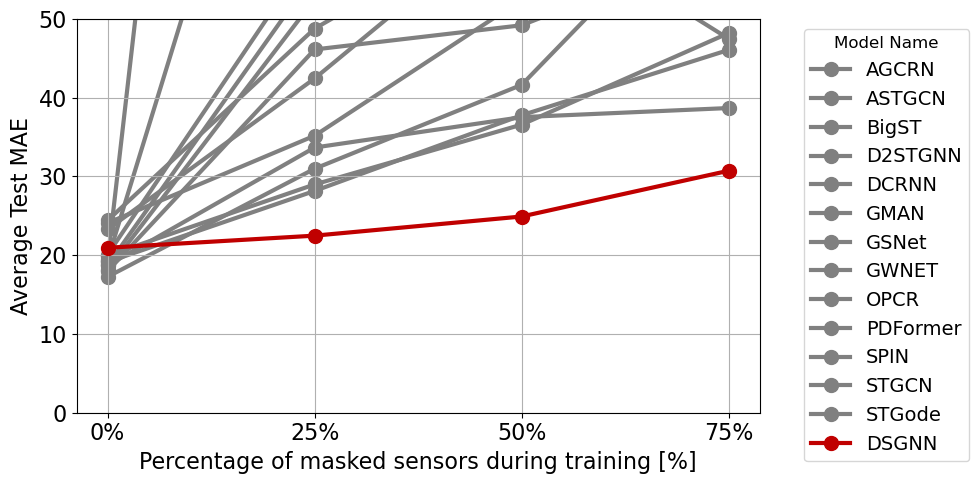

In [26]:
## make the same figure as in the previous cell but only the MAE panel with larger font and highlight DSGNN
import numpy as np

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(1,1,1)

# plot all lines in gray
for col in pivoted_tmp_mae.columns:
    if col != 'DSGNN':
        ax.plot(pivoted_tmp_mae.index, pivoted_tmp_mae[col], marker='o',
                color='gray', linewidth=3, markersize=10, label=col, zorder=1)

# plot DSGNN on top
if 'DSGNN' in pivoted_tmp_mae.columns:
    ax.plot(pivoted_tmp_mae.index, pivoted_tmp_mae['DSGNN'], marker='o',
            color='#C00000', linewidth=3, markersize=10, label='DSGNN', zorder=2)

ax.set_ylim(0,50)
# ax.set_title('MAE vs Mask Type', fontsize=16)
ax.set_ylabel('Average Test MAE', fontsize=16)
ax.set_xlabel('Percentage of masked sensors during training [%]', fontsize=16)

ax.set_xticks(np.arange(len(pivoted_tmp_mae.index)))
ax.set_xticklabels([f'{x}%' for x in np.arange(len(pivoted_tmp_mae.index)) * 25], fontsize=16)
## set fontsize of y ticks
ax.tick_params(axis='y', labelsize=16)

ax.grid(True)
plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=14)
plt.tight_layout()
plt.savefig('img/mae_vs_mask_type_highlight_dsgnn.png', dpi=300)


In [74]:
tmp.pivot(index='model_name', columns='mask_name', values='test_avg_mae').style\
.highlight_min(axis=0, color='lightgreen')\
.format("{:.4f}")

mask_name,block_missing_005,no_mask,point_missing_050,point_missing_075,point_missing_075_only_input,point_missing_095,tr_drop_025,tr_drop_050,tr_drop_075
model_name,,,,,,,,,
AGCRN,16.8363,18.1317,9.6666,5.3005,21.4105,1.2255,52.5256,87.5850,116.0451
ASTGCN,25.2437,24.4177,16.5722,9.5992,38.1306,2.4691,48.7797,63.9404,47.4897
BigST,17.3839,18.6997,10.0785,5.2754,22.0993,1.1696,33.6769,37.5376,38.6941
D2STGNN,16.0355,17.2583,9.1492,4.9211,20.3211,1.1603,30.9889,41.6395,68.7393
DCRNN,21.0151,23.2737,11.6995,6.3723,28.4335,1.7208,42.4516,64.1522,117.1695
DSGNN,22.9460,21.4140,11.9584,6.7447,31.7075,1.5500,22.4869,24.9185,30.7311
GMAN,18.7440,18.7184,10.8755,6.2420,25.1133,1.7723,55.7597,102.8195,124.1739
GSNet,19.3542,19.9557,11.4895,6.3536,26.4924,1.4512,28.9913,36.5885,48.2183
GWNET,16.7246,17.9719,9.4145,5.1262,20.5835,1.5451,46.1308,49.2055,59.4617


In [75]:
tmp

,model_name,mask_name,withMD,mask_iter,test_avg_mae,test_available_sensors_avg_mae,test_avg_mape,test_avg_rmse,train_mask
0,AGCRN,block_missing_005,True,2.0,16.836270,NaN,0.125431,32.769854,0.0
1,AGCRN,no_mask,True,0.0,18.131707,NaN,0.134091,32.557434,0.0
2,AGCRN,point_missing_050,True,2.0,9.666596,NaN,0.072079,25.353580,0.0
3,AGCRN,point_missing_075,True,2.0,5.300484,NaN,0.038832,19.603257,0.0
4,AGCRN,point_missing_075_only_input,True,2.0,21.410469,NaN,0.157936,39.011408,0.0
...,...,...,...,...,...,...,...,...,...
113,STGode,point_missing_075_only_input,True,2.0,23.995571,NaN,0.168651,43.236645,0.0
114,STGode,point_missing_095,True,2.0,1.403120,NaN,0.009841,11.440913,0.0
115,STGode,tr_drop_025,True,2.0,248.375710,NaN,3.722584,516.124731,0.0
116,STGode,tr_drop_050,True,2.0,408.194311,NaN,8.495362,642.755466,0.0


In [1]:
import numpy as np

mat = np.load('./results/SD/DSGNN/02-06_11-00-09_9c8312/embedding_evolution.npy')

In [2]:
# runs = {
#     'fixed50' : {'path': './results/SD/DSGNN/02-06_11-00-05_366428/'},
#     'fixed100' : {'path': './results/SD/DSGNN/02-06_11-00-05_d5f9dd/'},
#     'fixed200' : {'path': './results/SD/DSGNN/02-06_11-00-05_6e9ffe/'},
#     'fixed350' : {'path': './results/SD/DSGNN/02-06_11-00-05_d6c4c1/'},
#     'static_dsn' : {'path': './results/SD/DSGNN/02-06_11-00-09_9c8312/'},
#     'identity' : {'path': './results/SD/DSGNN/02-06_11-00-09_962f4d/'},
# }

runs = {
    'fixed50' : {'path': './results/SD/DSGNN/02-09_09-32-29_a3c515/'},
    'fixed100' : {'path': './results/SD/DSGNN/02-09_09-32-29_ba154d/'},
    'fixed200' : {'path': './results/SD/DSGNN/02-09_09-32-29_c2fcae/'},
    'fixed350' : {'path': './results/SD/DSGNN/02-09_09-32-29_d93d79/'},
    'static_dsn' : {'path': './results/SD/DSGNN/02-09_09-32-29_9860b9/'},
    'identity' : {'path': './results/SD/DSGNN/02-09_09-32-29_24e7fd/'},
}

for key in runs.keys():
    mat = np.load(runs[key]['path'] + 'embedding_evolution.npy')
    runs[key]['mat'] = mat[:64]


for key in runs.keys():
    
    with open(runs[key]['path'] + 'record_s2023.log', 'r') as f:
        logs = f.readlines()

    for line in logs:
        if 'Average Test MAE: ' in line:
            runs[key]['test_avg_mae'] = float(line.split('Average Test MAE: ')[-1].split(',')[0])


In [3]:
for key in runs.keys():
    mat = runs[key]['mat']

    flatten_mat = np.concatenate(mat, axis=0)

    labels = np.arange(mat.shape[0]).reshape(mat.shape[0], 1)
    labels = np.repeat(labels, mat.shape[1], axis=1)
    labels = labels.flatten()

    runs[key]['labels'] = labels

    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=300)
    tsne_result = tsne.fit_transform(flatten_mat)
    runs[key]['tsne'] = tsne_result



Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x152fe8bbb7e0>
Traceback (most recent call last):
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line

62
63
60
62
63
63


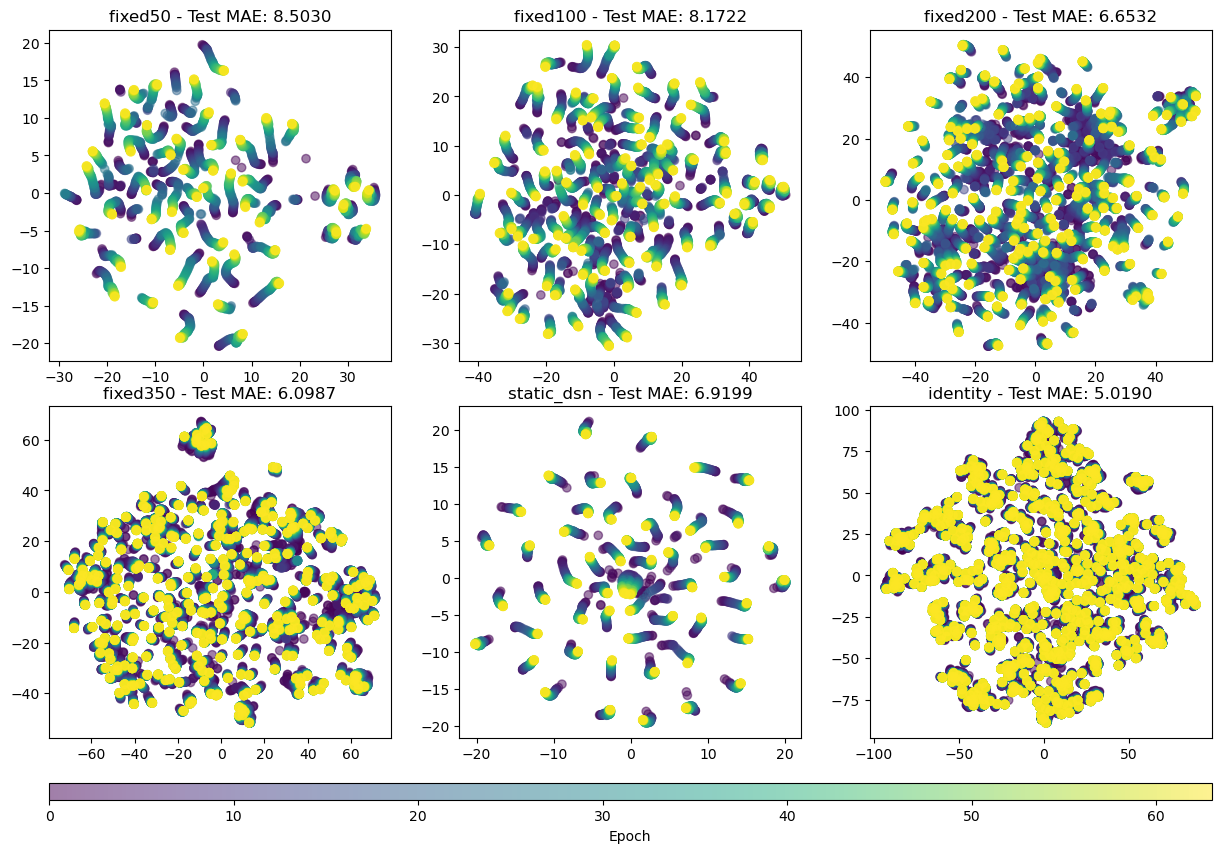

In [4]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(15,10))

grid_spec = fig.add_gridspec(3, 3, height_ratios=[1, 1, 0.05])

for i, key in enumerate(runs.keys()):
    ax = fig.add_subplot(grid_spec[i//3, i%3])
    tsne_result = runs[key]['tsne']
    labels = runs[key]['labels']
    print(labels.max())
    ax.scatter(tsne_result[:, 0], tsne_result[:, 1], label=key, alpha=0.5, c = labels, cmap='viridis')

    ax.set_title(f'{key} - Test MAE: {runs[key]["test_avg_mae"]:.4f}')

plt.colorbar(ax.collections[0], cax=fig.add_subplot(grid_spec[2,:]), label='Epoch', orientation='horizontal')


Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x14e9e5ba8fe0>
Traceback (most recent call last):
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line

/tmp/ipykernel_787662/985983257.py:14: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(tsne_result[labels == 1, 0], tsne_result[labels == 1, 1], label='fixed50', alpha=0.5, cmap='viridis')
/tmp/ipykernel_787662/985983257.py:15: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(tsne_result[labels == 0, 0], tsne_result[labels == 0, 1], label='static_dsn (54)', alpha=0.5, cmap='viridis')


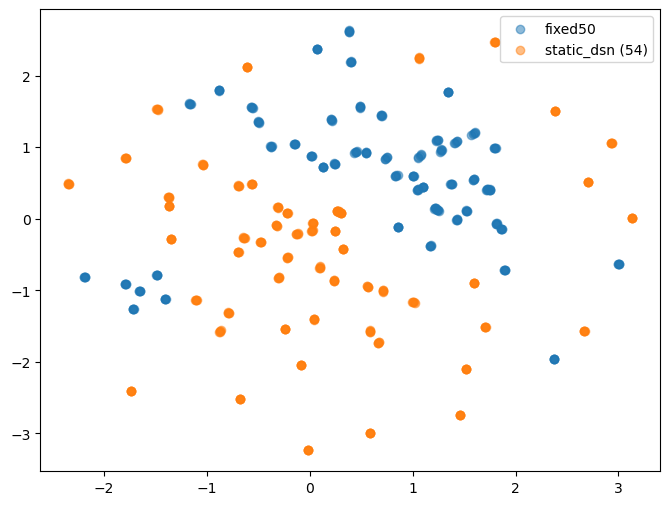

In [13]:

flatten_mat_f50 = np.concatenate(runs['fixed50']['mat'][-5:], axis=0)
flatten_mat_static_dsn = np.concatenate(runs['static_dsn']['mat'][-5:], axis=0)

labels_f50 = np.ones_like(flatten_mat_f50[..., 0])
labels_static_dsn = np.zeros_like(flatten_mat_static_dsn[..., 0])

labels = np.concatenate([labels_f50, labels_static_dsn], axis=0)
flatten_mat = np.concatenate([flatten_mat_f50, flatten_mat_static_dsn], axis=0)

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=300)
tsne_result = tsne.fit_transform(flatten_mat)
plt.figure(figsize=(8,6))
plt.scatter(tsne_result[labels == 1, 0], tsne_result[labels == 1, 1], label='fixed50', alpha=0.5, cmap='viridis')
plt.scatter(tsne_result[labels == 0, 0], tsne_result[labels == 0, 1], label='static_dsn (54)', alpha=0.5, cmap='viridis')
plt.legend()

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x14fdfdb5d300>
Traceback (most recent call last):
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line

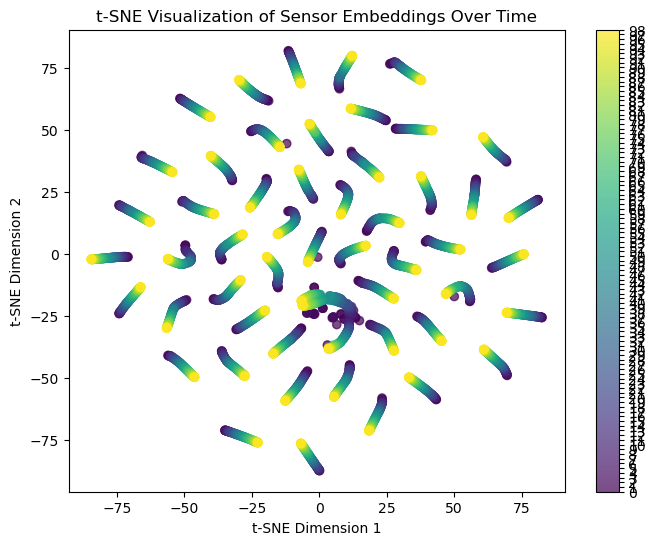

In [17]:
flatten_mat = np.concatenate(mat, axis=0)

labels = np.arange(mat.shape[0]).reshape(mat.shape[0], 1)
labels = np.repeat(labels, mat.shape[1], axis=1)
labels = labels.flatten()

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(flatten_mat)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, ticks=np.arange(mat.shape[0]))
plt.title('t-SNE Visualization of Sensor Embeddings Over Time')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()


In [19]:
mat[0].shape

(350, 64)

In [4]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=41)

embeddings_2d = tsne.fit_transform(mat[0])
# fig = plt.figure()
# ax = fig.add_subplot(1,1,1)
# ax.scatter(embeddings_2d[:,0], embeddings_2d[:,1])

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x151cced8d9e0>
Traceback (most recent call last):
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x151cc8dbef20>
Traceback (most recent call last):
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line

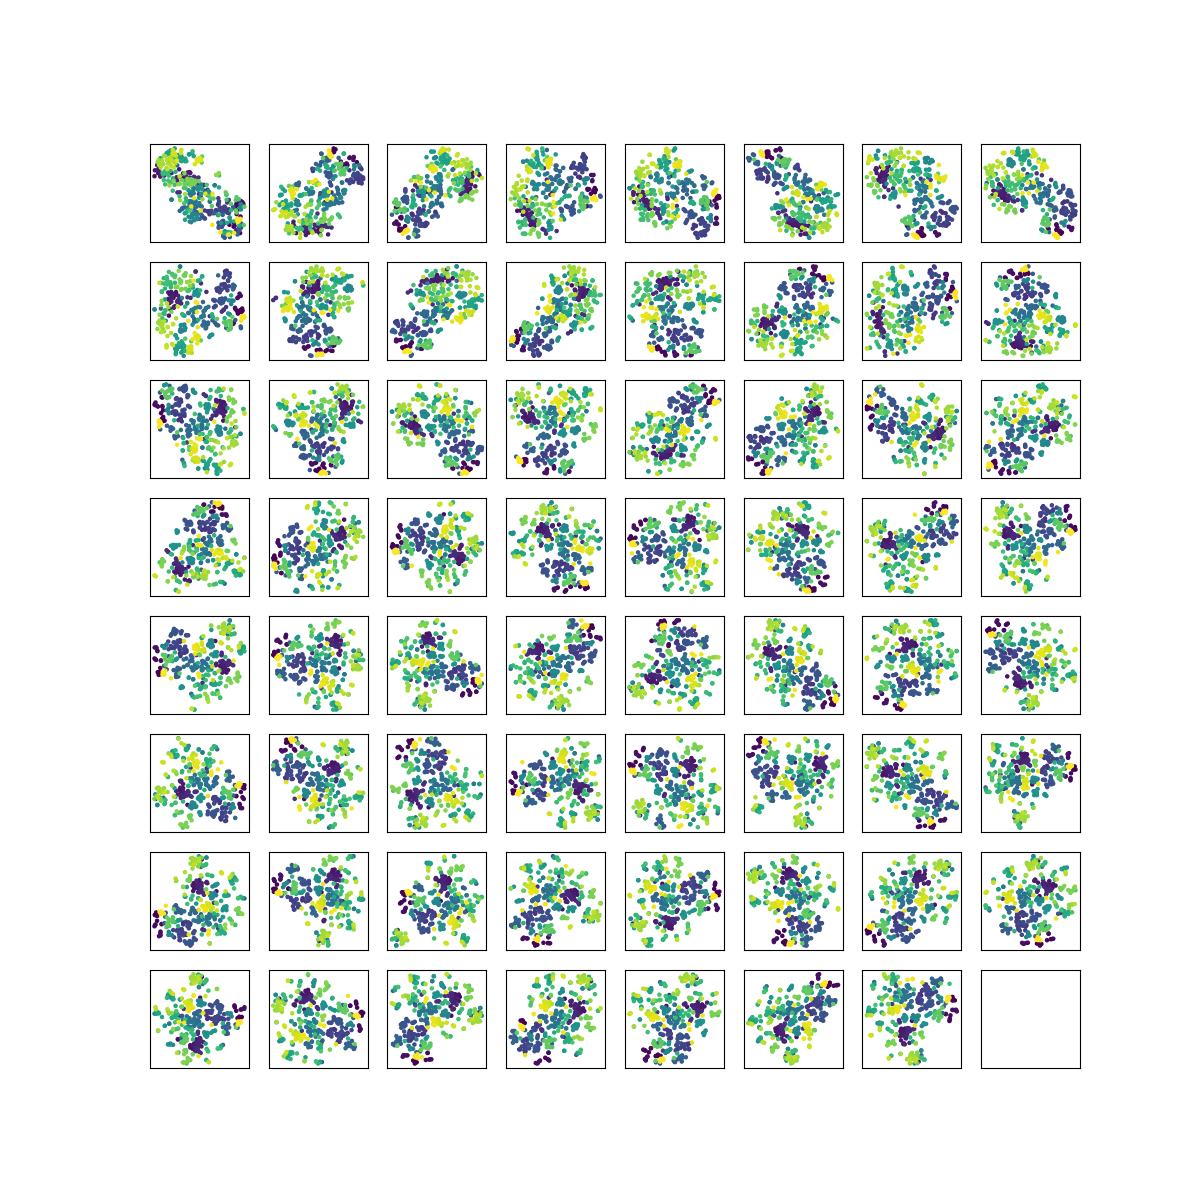

In [23]:
%matplotlib ipympl
# slider plot to visulize the different steps
import matplotlib.pyplot as plt

# gridspec with 8x8
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(8, 8, figure=fig)

for i in range(64):
    ax = fig.add_subplot(gs[i])
    if i < mat.shape[0]:
        tsne = TSNE(n_components=2, random_state=41)
        embeddings_2d = tsne.fit_transform(mat[i])
        ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, c = np.arange(mat.shape[-2]))
        # ax.scatter(mat[i,:, :2], mat[i,:, :2], s=5)
        
    ax.set_xticks([])
    ax.set_yticks([])

In [30]:
import xarray

IntSlider(value=0, max=63)

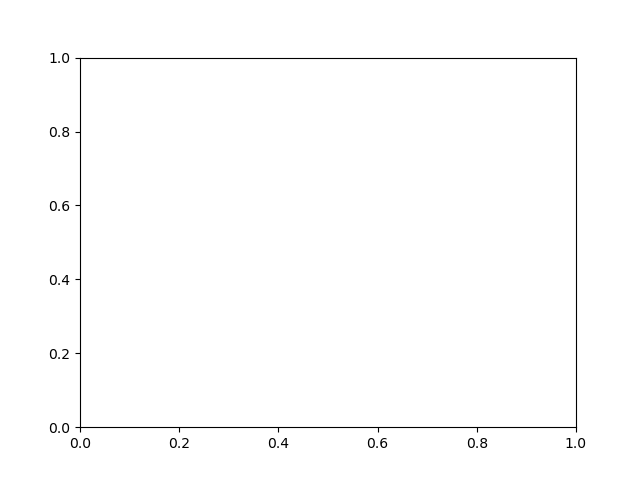

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x151c37beb6a0>
Traceback (most recent call last):
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
                   ^^^^^^^^^^^^^^^^^^
  File "/gxfs_home/geomar/smomw507/.conda/envs/multi_context2.0/lib/python3.11/site-packages/threadpoolctl.py", line

In [29]:
# make a slider to visualize the different steps
import ipywidgets as widgets
slider = widgets.IntSlider(min=0, max=63, step=1, value=0)



fig = plt.figure()
ax = fig.add_subplot(1,1,1)



def update_plot(change):
    # clear figure and plot the new one
    i = change['new']
    
    tsne = TSNE(n_components=2, random_state=41)
    embeddings_2d = tsne.fit_transform(mat[i])
    ax.clear()
    ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], s=5, c = np.arange(mat.shape[-2]))


slider.observe(update_plot, names='value')
display(slider)


## Paper Figures


## Accuracy as Latex table


In [30]:
import seaborn as sns
global_color_list = ['AGCRN', 'ASTGCN', 'BigST', 'D2STGNN', 'DCRNN', 'GMAN', 'GSNet', 'OPCR', 'SPIN', 'STGode', 'STGCN', 'PDFormer', 'DeepStateGNN']

global_ordering = ['DCRNN', 'AGCRN', 'STGCN', 'ASTGCN', 'GWNET', 'GMAN', 'PDFormer', 'D2STGNN', 'STGode', 'BigST', 'GSNet', 'SPIN', 'OPCR', 'DeepStateGNN']

global_color_dict = dict(zip(global_ordering, sns.color_palette("tab20").as_hex()[:len(global_ordering)]))


global_color_dict['DeepStateGNN'] = 'tab:blue'

global_category_dict = {
    'AGCRN':  'sensor-level',
    'ASTGCN': 'sensor-level',
    'STGCN': 'sensor-level',
    'GWNET': 'sensor-level',
    'GMAN': 'sensor-level',
    'PDFormer': 'sensor-level',
    'DCRNN': 'sensor-level',
    'D2STGNN': 'sensor-level',
    'STGode': 'sensor-level',
    'BigST': 'scalable sensor-level',
    'GSNet': 'scalable sensor-level',
    'SPIN': 'sparse data reconstruction',
    'OPCR': 'sparse data reconstruction',
    'DeepStateGNN': 'cool',
    'DSGNN': 'cool'
}

# create a dataframe from the global category dict
global_category_df = pd.DataFrame.from_dict(global_category_dict, orient='index', columns=['category'])
global_category_df.index.name = 'model_name'

In [6]:
runs_withMD = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["withMD"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None,'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)
runs_inference_time = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["inference_time_benchmark"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None,'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)

all_runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["withMD"]}}, {'config.mask_name': {"$in": [None,'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)

pdformer_runs = all_runs[all_runs['model_name'] == 'PDFormer']
not_finished_pdformer = pdformer_runs[pdformer_runs['state'] != 'finished']
valid_not_finished_pdformer = not_finished_pdformer[~not_finished_pdformer.loc[:, 'test_avg_mae'].isna()]

runs_withMD = pd.concat([runs_withMD, valid_not_finished_pdformer], ignore_index=True)

runs_withMD


100%|██████████| 337/337 [00:02<00:00, 135.77it/s]


,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,n_hid,static_prefilter_mode,gcn_layers,ablation_concat_queries,...,test_avg_rmse,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,train_mask
0,PDFormer,point_missing_095,4,SD,None,NaN,NaN,None,NaN,None,...,10.838809,PDFormer_SD_2019_PDFormer_point_missing_095_4_...,100.0,finished,[withMD],None,33.928579,True,False,False
1,PDFormer,point_missing_075,4,SD,None,NaN,NaN,None,NaN,None,...,20.382137,PDFormer_SD_2019_PDFormer_point_missing_075_4_...,100.0,finished,[withMD],None,83.828264,True,False,False
2,PDFormer,point_missing_050,4,SD,None,NaN,NaN,None,NaN,None,...,26.215297,PDFormer_SD_2019_PDFormer_point_missing_050_4_...,100.0,finished,[withMD],None,33.157575,True,False,False
3,PDFormer,no_mask,0,SD,None,NaN,NaN,None,NaN,None,...,36.049268,PDFormer_SD_2019_PDFormer_nomask_2026-05-01 11:24,100.0,finished,[withMD],None,83.494009,True,False,False
4,PDFormer,point_missing_095,3,SD,None,NaN,NaN,None,NaN,None,...,11.003804,PDFormer_SD_2019_PDFormer_point_missing_095_3_...,100.0,finished,[withMD],None,83.609611,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,PDFormer,no_mask,0,SD,None,NaN,NaN,None,NaN,None,...,36.049268,PDFormer_SD_2019_PDFormer_nomask_2026-04-30 15:21,100.0,failed,[withMD],None,82.606599,True,False,False
272,PDFormer,point_missing_095,0,SD,None,NaN,NaN,None,NaN,None,...,11.020370,PDFormer_SD_2019_PDFormer_point_missing_095_0_...,100.0,failed,[withMD],None,34.433352,True,False,False
273,PDFormer,point_missing_075,0,SD,None,NaN,NaN,None,NaN,None,...,20.570414,PDFormer_SD_2019_PDFormer_point_missing_075_0_...,100.0,failed,[withMD],None,33.965800,True,False,False
274,PDFormer,point_missing_050,0,SD,None,NaN,NaN,None,NaN,None,...,26.726623,PDFormer_SD_2019_PDFormer_point_missing_050_0_...,100.0,failed,[withMD],None,83.463828,True,False,False


In [16]:
pdformer_runs.groupby(['mask_name', 'model_name']).mean().loc[:, ['benchmark_inference_mean_time', 'benchmark_inference_std_time']]

,,benchmark_inference_mean_time,benchmark_inference_std_time
mask_name,model_name,,
no_mask,PDFormer,NaN,NaN
point_missing_050,PDFormer,0.004426,0.000217
point_missing_075,PDFormer,0.004547,0.000245
point_missing_095,PDFormer,NaN,NaN


In [45]:
category_dict = {
    'sensor-level': 'o',
    'scalable sensor-level': 'X',
    'sparse data reconstruction': 's',
    'cool': 'D'
}

In [8]:
runs_inference_time

,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,n_hid,static_prefilter_mode,gcn_layers,ablation_concat_queries,...,test_avg_rmse,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,train_mask
0,PDFormer,point_missing_095,0,SD,None,NaN,NaN,None,NaN,None,...,37.299651,PDFormer_SD_2019_PDFormer_point_missing_095_0_...,1,finished,[inference_time_benchmark],None,33.725076,False,False,False
1,PDFormer,point_missing_075,0,SD,None,NaN,NaN,None,NaN,None,...,82.446673,PDFormer_SD_2019_PDFormer_point_missing_075_0_...,1,finished,[inference_time_benchmark],None,35.837871,False,False,False
2,PDFormer,point_missing_050,0,SD,None,NaN,NaN,None,NaN,None,...,116.393558,PDFormer_SD_2019_PDFormer_point_missing_050_0_...,1,finished,[inference_time_benchmark],None,33.926377,False,False,False
3,PDFormer,no_mask,0,SD,None,NaN,NaN,None,NaN,None,...,165.361389,PDFormer_SD_2019_PDFormer_nomask_2026-05-01 15:07,1,finished,[inference_time_benchmark],None,33.319011,False,False,False
4,DSGNN,point_missing_075,2,SD,None,32.0,64.0,static_dsn,2.0,True,...,63.255622,DSGNN_SD_2019_DSGNN_point_missing_075_2_2026-0...,1,finished,[inference_time_benchmark],None,10.210732,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,AGCRN,no_mask,0,SD,None,NaN,NaN,None,NaN,None,...,205.319274,AGCRN_SD_2019_AGCRN_nomask_2026-04-28 09:36,1,finished,[inference_time_benchmark],None,16.055919,False,False,False
156,GSNet,no_mask,0,SD,None,NaN,NaN,None,NaN,None,...,124.597441,GSNet_SD_2019_GSNet_nomask_2026-04-28 09:36,1,finished,[inference_time_benchmark],None,10.212972,False,False,False
157,STGCN,no_mask,0,SD,None,NaN,NaN,None,NaN,None,...,124.558636,STGCN_SD_2019_STGCN_nomask_2026-04-28 09:36,1,finished,[inference_time_benchmark],None,13.113229,False,False,False
158,BigST,no_mask,0,SD,None,NaN,NaN,None,NaN,None,...,141.938080,BigST_SD_2019_BigST_nomask_2026-04-28 09:36,1,finished,[inference_time_benchmark],None,16.013421,False,False,False


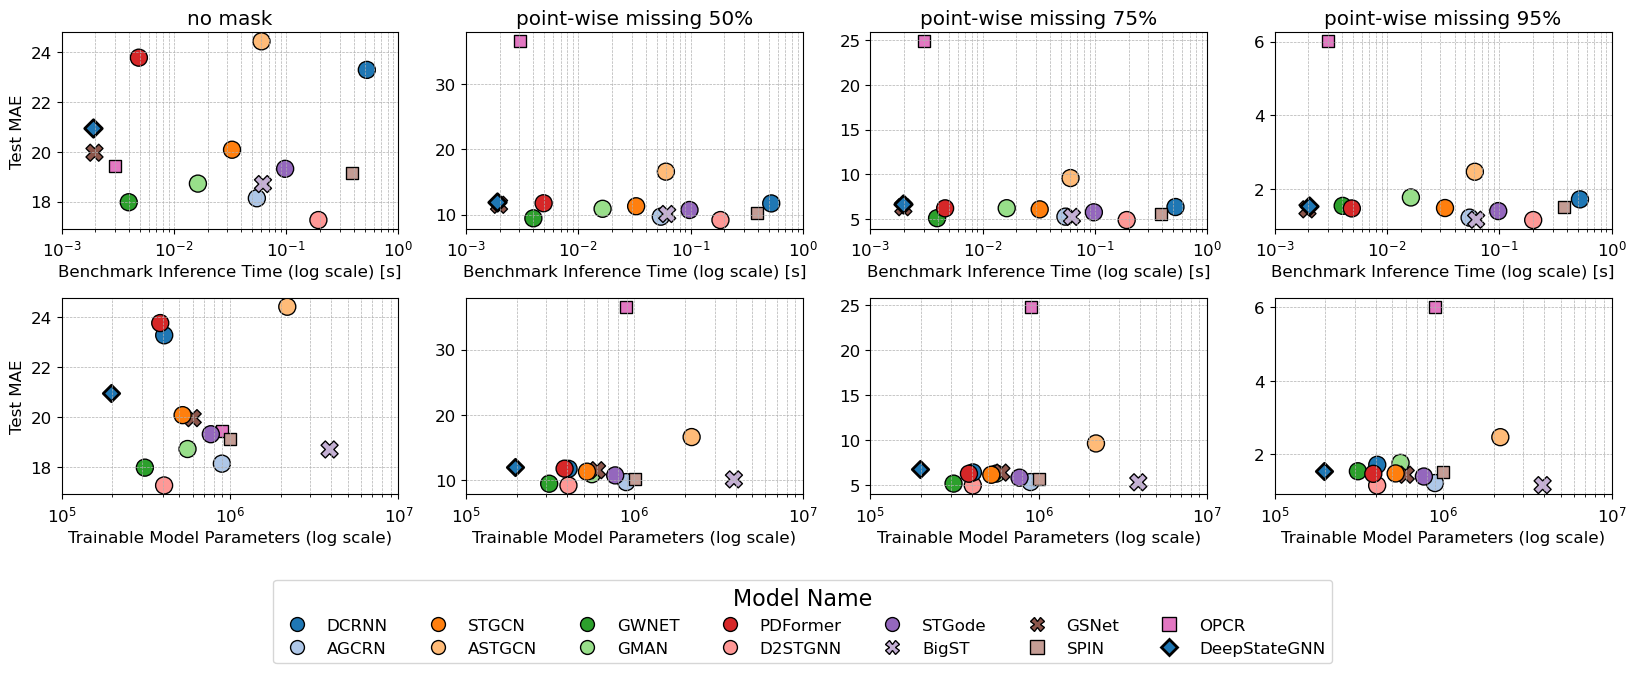

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
runs_inference_time = runs_inference_time.groupby(['mask_name', 'model_name']).mean().loc[:, ['benchmark_inference_mean_time', 'benchmark_inference_std_time']] 
grouped_sd_runs = runs_withMD.groupby(['mask_name', 'model_name']).mean().loc[:, ['test_avg_mae']] 
grouped_sd_runs = grouped_sd_runs.join(global_category_df, on='model_name', how='left')

joined_metrics = grouped_sd_runs.join(runs_inference_time, on=['mask_name', 'model_name'])

df = pd.read_csv('model_parameters.csv')

astgcn_org_gba = int(df.loc[df['Baseline'] == 'ASTGCN', 'GBA'].values[0])
# df.loc[df['Baseline'] == 'ASTGCN', 'GBA'] = 4_500_000

joined_metrics = joined_metrics.reset_index().set_index('model_name').join(df.set_index('Baseline').loc[:, ['SD']].rename(columns={'SD': 'model_paramters_sd'}), on='model_name').reset_index().set_index(['mask_name', 'model_name'])

mask_bla = (~ pd.isna(joined_metrics)).all(axis=1).reset_index().groupby('model_name').all().reset_index()
valid_models = mask_bla[mask_bla.iloc[:, 2]].model_name
# valid_models = valid_models[~valid_models.str.contains('OPCR')]
joined_metrics = joined_metrics[joined_metrics.index.get_level_values('model_name').isin(valid_models)]

joined_metrics = joined_metrics.rename(index={'DSGNN': 'DeepStateGNN'})

## set fontsize to 12
plt.rcParams.update({'font.size': 12})

import matplotlib.pyplot as plt
import seaborn as sns

mask_dictionary = {
    'no_mask': 'no mask',
    'point_missing_050': 'point-wise missing 50%',
    'point_missing_075': 'point-wise missing 75%',
    'point_missing_095': 'point-wise missing 95%',
    'tr_drop_025': 'unseen-sensor 25%',
    'tr_drop_050': 'unseen-sensor 50%',
    'tr_drop_075': 'unseen-sensor 75%',
}


fig = plt.figure(figsize=(20, 6))

mask_i = 0
for mask in joined_metrics.index.get_level_values('mask_name').unique():
    mask_data = joined_metrics.loc[mask].reset_index()
    mask_data = mask_data[mask_data.model_name != 'DeepStateGNN']
    # plt.errorbar(mask_data['benchmark_inference_mean_time'], mask_data['test_avg_mae'], yerr=mask_data['benchmark_inference_std_time'], fmt='o', label=mask)
    ax = fig.add_subplot(2, 4, mask_i + 1)
    
    sns.scatterplot(data=mask_data, x='benchmark_inference_mean_time', y='test_avg_mae', hue='model_name', s=150, palette=global_color_dict, ax = ax, legend = False, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
    sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='benchmark_inference_mean_time', y='test_avg_mae', hue='model_name', s=80, ax = ax, legend = False, edgecolor='black',marker='D', linewidth=2)
    # if mask_i == 3:
    #     sns.move_legend(ax, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
    ax.set_title(f'{mask_dictionary[mask]}')
    plt.xscale('log')
    ax.grid(True, which="both", ls="--", linewidth=0.5)
    
    ax.set_xlabel('Benchmark Inference Time (log scale) [s]')
    
    if mask_i == 0:
        ax.set_ylabel('Test MAE')
    else: 
        ax.set_ylabel(None)
        
    ax.set_xlim(10**-3, 1)
    
    
    ax_model_para = fig.add_subplot(2, 4, mask_i + 1 + 4)
    
    ax_model_para.grid(True, which="both", ls="--", linewidth=0.5)
    sns.scatterplot(data=mask_data, x='model_paramters_sd', y='test_avg_mae', hue='model_name', s=150, palette=global_color_dict, ax = ax_model_para, legend = mask_i == 3, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
    sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='model_paramters_sd', y='test_avg_mae', hue='model_name', s=70, ax = ax_model_para, legend = mask_i == 3, edgecolor='black',marker='D', linewidth=2)
    
    if mask_i == 3:
        # sns.move_legend(ax_model_para, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
        handles, labels = ax_model_para.get_legend_handles_labels()
        label_index = labels.index('category')
        
        # change the shape of the handles to squares
        for i in range(1, label_index):
            handles[i].set_marker(category_dict[global_category_dict[labels[i]]])
            handles[i].set_markersize(10)
        
        plt.legend(handles = handles[1:label_index] + handles[-1:], labels = labels[1:label_index] + labels[-1:], title='Model Name', bbox_to_anchor=(-1.4, -.9), loc='lower center', ncol = 7, title_fontsize=16)
    ax_model_para.set_title(None)
    plt.xscale('log')
    
    ax_model_para.set_xlabel('Trainable Model Parameters (log scale)')
    if mask_i == 0:
        ax_model_para.set_ylabel('Test MAE')
    else: 
        ax_model_para.set_ylabel(None)

    ax_model_para.set_xlim(10**5, 10**7)
    mask_i += 1
    
plt.subplots_adjust(hspace=.35)

    
    
# plt.tight_layout()
plt.savefig('img/inference_time_vs_mae.png', dpi=300, bbox_inches='tight')

In [10]:
joined_metrics

test_avg_mae                    category  \
mask_name         model_name                                               
no_mask           AGCRN            18.131707                sensor-level   
                  ASTGCN           24.417712                sensor-level   
                  BigST            18.699735       scalable sensor-level   
                  D2STGNN          17.258275                sensor-level   
                  DCRNN            23.273699                sensor-level   
                  DeepStateGNN     20.948458                        cool   
                  GMAN             18.718387                sensor-level   
                  GSNet            19.955710       scalable sensor-level   
                  GWNET            17.971938                sensor-level   
                  OPCR             19.423573  sparse data reconstruction   
                  PDFormer         23.763073                sensor-level   
                  SPIN             19.134203  sparse data reconstruction   
                  STGCN            20.075139                sensor-level   
                  STGode           19.311021                sensor-level   
point_missing_050 AGCRN             9.666596                sensor-level   
                  ASTGCN           16.572246                sensor-level   
                  BigST            10.078496       scalable sensor-level   
                  D2STGNN           9.149183                sensor-level   
                  DCRNN            11.699508                sensor-level   
                  DeepStateGNN     11.958378                        cool   
                  GMAN             10.875465                sensor-level   
                  GSNet            11.489498       scalable sensor-level   
                  GWNET             9.414480                sensor-level   
                  OPCR             36.563284  sparse data reconstruction   
                  PDFormer         11.725754                sensor-level   
                  SPIN             10.189222  sparse data reconstruction   
                  STGCN            11.265112                sensor-level   
                  STGode           10.693923                sensor-level   
point_missing_075 AGCRN             5.300484                sensor-level   
                  ASTGCN            9.599220                sensor-level   
                  BigST             5.275447       scalable sensor-level   
                  D2STGNN           4.921094                sensor-level   
                  DCRNN             6.372282                sensor-level   
                  DeepStateGNN      6.744733                        cool   
                  GMAN              6.242019                sensor-level   
                  GSNet             6.353598       scalable sensor-level   
                  GWNET             5.126154                sensor-level   
                  OPCR             24.824007  sparse data reconstruction   
                  PDFormer          6.226564                sensor-level   
                  SPIN              5.589224  sparse data reconstruction   
                  STGCN             6.111835                sensor-level   
                  STGode            5.786696                sensor-level   
point_missing_095 AGCRN             1.225463                sensor-level   
                  ASTGCN            2.469138                sensor-level   
                  BigST             1.169573       scalable sensor-level   
                  D2STGNN           1.160263                sensor-level   
                  DCRNN             1.720761                sensor-level   
                  DeepStateGNN      1.550003                        cool   
                  GMAN              1.772345                sensor-level   
                  GSNet             1.451166       scalable sensor-level   
                  GWNET             1.545073                sensor-level   
    

In [28]:
runs_benchmark_GBA = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["benchmark_GBA"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None,'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)
runs_inference_time_GBA = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["inference_time_benchmark_GBA"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None,'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)


100%|██████████| 68/68 [00:00<00:00, 265.64it/s]


In [ ]:
['STGCN'] +list(mask_data.reset_index().model_name.unique())[:-1]

['AGCRN',
 'ASTGCN',
 'BigST',
 'D2STGNN',
 'DCRNN',
 'GMAN',
 'GSNet',
 'GWNET',
 'OPCR']

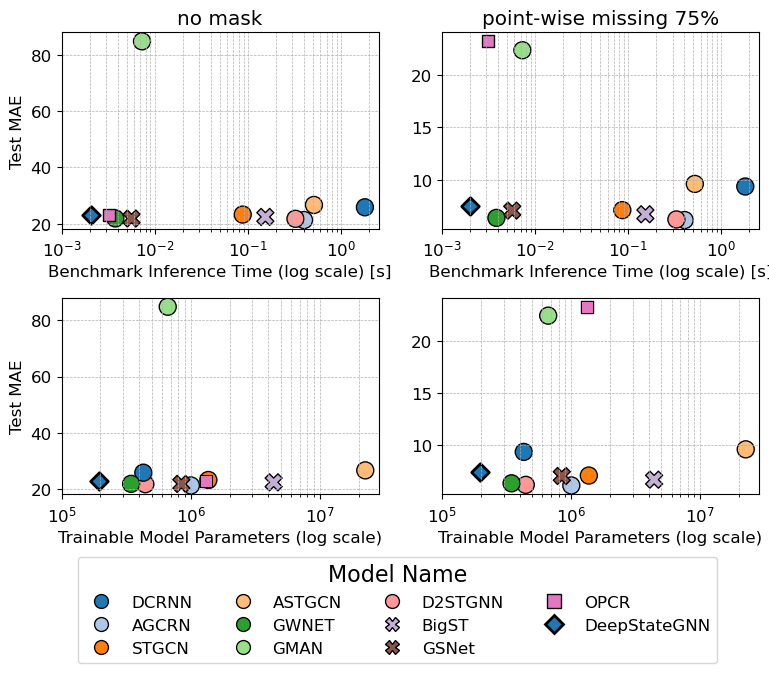

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
runs_inference_time_GBA = runs_inference_time_GBA.groupby(['mask_name', 'model_name']).mean().loc[:, ['benchmark_inference_mean_time', 'benchmark_inference_std_time']] 
grouped_gba_runs = runs_benchmark_GBA.groupby(['mask_name', 'model_name']).mean().loc[:, ['test_avg_mae']] 
grouped_gba_runs = grouped_gba_runs.join(global_category_df, on='model_name', how='left')


joined_metrics = grouped_gba_runs.join(runs_inference_time_GBA, on=['mask_name', 'model_name'])


mask_bla = (~ pd.isna(joined_metrics)).all(axis=1).reset_index().groupby('model_name').all().reset_index()
valid_models = mask_bla[mask_bla.iloc[:, 2]].model_name
joined_metrics = joined_metrics[joined_metrics.index.get_level_values('model_name').isin(valid_models)]


df = pd.read_csv('model_parameters.csv')

astgcn_org_gba = int(df.loc[df['Baseline'] == 'ASTGCN', 'GBA'].values[0])
# df.loc[df['Baseline'] == 'ASTGCN', 'GBA'] = 4_500_000

joined_metrics = joined_metrics.reset_index().set_index('model_name').join(df.set_index('Baseline').loc[:, ['GBA']].rename(columns={'GBA': 'model_paramters_gba'}), on='model_name').reset_index().set_index(['mask_name', 'model_name'])

# take all these model for which all the inference times are available and the test_avg_mae is available and model_paramters_gba is available
# joined_metrics = joined_metrics.dropna(subset=['benchmark_inference_mean_time', 'test_avg_mae', 'model_paramters_gba'])
joined_metrics = joined_metrics.rename(index={'DSGNN': 'DeepStateGNN'})

## set fontsize to 12
plt.rcParams.update({'font.size': 12})

import matplotlib.pyplot as plt
import seaborn as sns

mask_dictionary = {
    'no_mask': 'no mask',
    'point_missing_050': 'point-wise missing 50%',
    'point_missing_075': 'point-wise missing 75%',
    'point_missing_095': 'point-wise missing 95%',
    'tr_drop_025': 'unseen-sensor 25%',
    'tr_drop_050': 'unseen-sensor 50%',
    'tr_drop_075': 'unseen-sensor 75%',
}


fig = plt.figure(figsize=(9, 6))

mask_i = 0
for mask in joined_metrics.index.get_level_values('mask_name').unique():
    mask_data = joined_metrics.loc[mask].reset_index()
    mask_data = mask_data[mask_data.model_name != 'DeepStateGNN']
    # plt.errorbar(mask_data['benchmark_inference_mean_time'], mask_data['test_avg_mae'], yerr=mask_data['benchmark_inference_std_time'], fmt='o', label=mask)
    ax = fig.add_subplot(2, 2, mask_i + 1)
    
    sns.scatterplot(data=mask_data, x='benchmark_inference_mean_time', y='test_avg_mae', hue='model_name', s=150, palette=global_color_dict, ax = ax, legend = False, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
    sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='benchmark_inference_mean_time', y='test_avg_mae', hue='model_name', s=80, ax = ax, legend = False, edgecolor='black',marker='D', linewidth=2)
    # if mask_i == 3:
    #     sns.move_legend(ax, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
    ax.set_title(f'{mask_dictionary[mask]}')
    plt.xscale('log')
    ax.grid(True, which="both", ls="--", linewidth=0.5)
    
    ax.set_xlabel('Benchmark Inference Time (log scale) [s]')
    
    if mask_i == 0:
        ax.set_ylabel('Test MAE')
    else: 
        ax.set_ylabel(None)
    ax.set_xlim(10**-3, None)
    
    ax_model_para = fig.add_subplot(2, 2, mask_i + 1 + 2)
    
    ax_model_para.grid(True, which="both", ls="--", linewidth=0.5)
    sns.scatterplot(data=mask_data, x='model_paramters_gba', y='test_avg_mae', hue='model_name', s=150, palette=global_color_dict, ax = ax_model_para, legend = mask_i == 1, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
    sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='model_paramters_gba', y='test_avg_mae', hue='model_name', s=80, ax = ax_model_para, legend = mask_i == 1, edgecolor='black',marker='D', linewidth=2)
    sns.scatterplot(data=joined_metrics.loc[[(mask, 'OPCR')], :].reset_index(), x='model_paramters_gba', y='test_avg_mae', hue='model_name', s=85, ax = ax_model_para, legend =False,marker = 's',edgecolor='black', palette=global_color_dict)
    if mask_i == 1:
        # sns.move_legend(ax_model_para, "lower center", bbox_to_anchor=(-.15, -.9), ncol=4, title='Model Name')
        
        # sns.move_legend(ax_model_para, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
        handles, labels = ax_model_para.get_legend_handles_labels()
        label_index = labels.index('category')
        
        # change the shape of the handles to squares
        for i in range(1, label_index):
            handles[i].set_marker(category_dict[global_category_dict[labels[i]]])
            handles[i].set_markersize(10)
        
        plt.legend(handles = handles[1:label_index] + handles[-1:], labels = labels[1:label_index] + labels[-1:], title='Model Name', bbox_to_anchor=(-.14, -.9), loc='lower center', ncol = 4, title_fontsize=16)
    ax_model_para.set_title(None)
    plt.xscale('log')
    
    ax_model_para.set_xlabel('Trainable Model Parameters (log scale)')
    if mask_i == 0:
        ax_model_para.set_ylabel('Test MAE')
    else: 
        ax_model_para.set_ylabel(None)

    
    mask_i += 1
    ax_model_para.set_xlim(10**5, None)
    
plt.subplots_adjust(hspace=.35)

    
    
# plt.tight_layout()
plt.savefig('img/inference_time_vs_mae_gba.png', dpi=300, bbox_inches='tight')

['model_name', 'DCRNN', 'AGCRN', 'STGCN', 'ASTGCN', 'GWNET', 'GMAN', 'D2STGNN', 'BigST', 'GSNet', 'OPCR', 'category', 'sensor-level', 'scalable sensor-level', 'sparse data reconstruction', 'DSGNN']


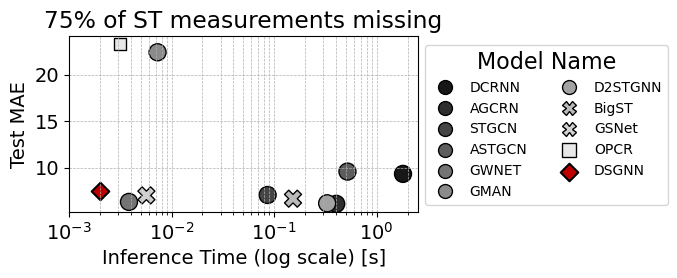

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
runs_inference_time_GBA = runs_inference_time_GBA.groupby(['mask_name', 'model_name']).mean().loc[:, ['benchmark_inference_mean_time', 'benchmark_inference_std_time']] 
grouped_gba_runs = runs_benchmark_GBA.groupby(['mask_name', 'model_name']).mean().loc[:, ['test_avg_mae']] 
grouped_gba_runs = grouped_gba_runs.join(global_category_df, on='model_name', how='left')


joined_metrics = grouped_gba_runs.join(runs_inference_time_GBA, on=['mask_name', 'model_name'])


mask_bla = (~ pd.isna(joined_metrics)).all(axis=1).reset_index().groupby('model_name').all().reset_index()
valid_models = mask_bla[mask_bla.iloc[:, 2]].model_name
joined_metrics = joined_metrics[joined_metrics.index.get_level_values('model_name').isin(valid_models)]


df = pd.read_csv('model_parameters.csv')

astgcn_org_gba = int(df.loc[df['Baseline'] == 'ASTGCN', 'GBA'].values[0])
# df.loc[df['Baseline'] == 'ASTGCN', 'GBA'] = 4_500_000

joined_metrics = joined_metrics.reset_index().set_index('model_name').join(df.set_index('Baseline').loc[:, ['GBA']].rename(columns={'GBA': 'model_paramters_gba'}), on='model_name').reset_index().set_index(['mask_name', 'model_name'])

# take all these model for which all the inference times are available and the test_avg_mae is available and model_paramters_gba is available
# joined_metrics = joined_metrics.dropna(subset=['benchmark_inference_mean_time', 'test_avg_mae', 'model_paramters_gba'])
joined_metrics = joined_metrics.rename(index={'DSGNN': 'DeepStateGNN'})

## set fontsize to 12
plt.rcParams.update({'font.size': 14})

import matplotlib.pyplot as plt
import seaborn as sns

mask_dictionary = {
    'no_mask': 'no mask',
    'point_missing_050': 'point-wise missing 50%',
    'point_missing_075': '75% of ST measurements missing',
    'point_missing_095': 'point-wise missing 95%',
    'tr_drop_025': 'unseen-sensor 25%',
    'tr_drop_050': 'unseen-sensor 50%',
    'tr_drop_075': 'unseen-sensor 75%',
}


fig = plt.figure(figsize=(7, 3))

mask_i = 0
for mask in ['point_missing_075']:# joined_metrics.index.get_level_values('mask_name').unique():
    mask_data = joined_metrics.loc[mask].reset_index()
    mask_data = mask_data[mask_data.model_name != 'DeepStateGNN']
    # plt.errorbar(mask_data['benchmark_inference_mean_time'], mask_data['test_avg_mae'], yerr=mask_data['benchmark_inference_std_time'], fmt='o', label=mask)
    ax = fig.add_subplot(1, 1, mask_i + 1)
    
    sns.scatterplot(data=mask_data, x='benchmark_inference_mean_time', y='test_avg_mae', hue='model_name', s=150, palette='gray', ax = ax, legend = True, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
    dsgnscatter = sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='benchmark_inference_mean_time', y='test_avg_mae', s=80, ax = ax, legend = True, edgecolor='black',marker='D', linewidth=1.5, color = '#C00000', label = 'DSGNN')
    # if mask_i == 3:
    #     sns.move_legend(ax, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
    ax.set_title(f'{mask_dictionary[mask]}')
    plt.xscale('log')
    ax.grid(True, which="both", ls="--", linewidth=0.5)
    
    ax.set_xlabel('Inference Time (log scale) [s]')
    
    if mask_i == 0:
        ax.set_ylabel('Test MAE')
    else: 
        ax.set_ylabel(None)
    ax.set_xlim(10**-3, None)
    
    handles, labels = ax.get_legend_handles_labels()
    print(labels)
    label_index = labels.index('category')
    
    # change the shape of the handles to squares
    for i in range(1, label_index):
        handles[i].set_marker(category_dict[global_category_dict[labels[i]]])
        handles[i].set_markersize(10)
    plt.legend(handles = handles[1:label_index] + handles[-1:], labels = labels[1:label_index] + labels[-1:], title='Model Name', bbox_to_anchor=(1., 0), loc='lower left', ncol = 2, title_fontsize=16, fontsize=10)
    
    
    # ax_model_para = fig.add_subplot(2, 2, mask_i + 1 + 2)
    
    # ax_model_para.grid(True, which="both", ls="--", linewidth=0.5)
    # sns.scatterplot(data=mask_data, x='model_paramters_gba', y='test_avg_mae', hue='model_name', s=150, palette=global_color_dict, ax = ax_model_para, legend = mask_i == 1, edgecolor='black', style= 'category', hue_order =[model for model in global_ordering if model in mask_data.reset_index().model_name.unique()])
    # sns.scatterplot(data=joined_metrics.loc[[(mask, 'DeepStateGNN')], :].reset_index(), x='model_paramters_gba', y='test_avg_mae', hue='model_name', s=80, ax = ax_model_para, legend = mask_i == 1, edgecolor='black',marker='D', linewidth=2)
    # sns.scatterplot(data=joined_metrics.loc[[(mask, 'OPCR')], :].reset_index(), x='model_paramters_gba', y='test_avg_mae', hue='model_name', s=85, ax = ax_model_para, legend =False,marker = 's',edgecolor='black', palette=global_color_dict)
    # if mask_i == 1:
    #     # sns.move_legend(ax_model_para, "lower center", bbox_to_anchor=(-.15, -.9), ncol=4, title='Model Name')
        
    #     # sns.move_legend(ax_model_para, "lower center", bbox_to_anchor=(-1.4, -.7), ncol=7, title='Model Name')
    #     handles, labels = ax_model_para.get_legend_handles_labels()
    #     label_index = labels.index('category')
        
    #     # change the shape of the handles to squares
    #     for i in range(1, label_index):
    #         handles[i].set_marker(category_dict[global_category_dict[labels[i]]])
    #         handles[i].set_markersize(10)
        
    #     plt.legend(handles = handles[1:label_index] + handles[-1:], labels = labels[1:label_index] + labels[-1:], title='Model Name', bbox_to_anchor=(-.14, -.9), loc='lower center', ncol = 4, title_fontsize=16)
    # ax_model_para.set_title(None)
    # plt.xscale('log')
    
    # ax_model_para.set_xlabel('Trainable Model Parameters (log scale)')
    # if mask_i == 0:
    #     ax_model_para.set_ylabel('Test MAE')
    # else: 
    #     ax_model_para.set_ylabel(None)

    
    # mask_i += 1
    # ax_model_para.set_xlim(10**5, None)
    
# plt.subplots_adjust(hspace=.35)

    
    
fig.tight_layout()
plt.savefig('img/DISS_inference_time_vs_mae_gba.png', dpi=300, bbox_inches='tight')

In [41]:
runs_withMD.set_index(['mask_name', 'model_name']).loc[[('no_mask', 'DSGNN')], :].reset_index().loc[:, ['test_avg_mae', 'name', 'tags']]

,test_avg_mae,name,tags
0,21.024061,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 14:46,[withMD]
1,20.902654,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 13:55,[withMD]
2,21.024061,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 12:24,[withMD]
3,21.024061,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 11:22,[withMD]
4,20.767451,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 11:22,[withMD]


In [42]:
runs_withMD.set_index(['mask_name', 'model_name']).loc[[('no_mask', 'DSGNN')], :].reset_index().loc[:, ['test_avg_mae', 'name', 'tags']]


,test_avg_mae,name,tags
0,21.024061,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 14:46,[withMD]
1,20.902654,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 13:55,[withMD]
2,21.024061,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 12:24,[withMD]
3,21.024061,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 11:22,[withMD]
4,20.767451,DSGNN_SD_2019_DSGNN_nomask_2026-04-20 11:22,[withMD]


In [11]:
runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["withMD", "benchmark_GBA"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None, "tr_drop_025", "tr_drop_050", "tr_drop_075",'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)

all_runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["withMD", "benchmark_GBA"]}}, {'config.mask_name': {"$in": [None, "tr_drop_025", "tr_drop_050", "tr_drop_075",'point_missing_050', 'point_missing_075', 'point_missing_095']}}]}), access_metadata = False)

pdformer_runs = all_runs[all_runs['model_name'] == 'PDFormer']
not_finished_pdformer = pdformer_runs[pdformer_runs['state'] != 'finished']
valid_not_finished_pdformer = not_finished_pdformer[~not_finished_pdformer.loc[:, 'test_avg_mae'].isna()]

runs = pd.concat([runs, valid_not_finished_pdformer], ignore_index=True)

runs

100%|██████████| 756/756 [00:06<00:00, 117.84it/s]


,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,n_hid,static_prefilter_mode,gcn_layers,ablation_concat_queries,...,test_avg_rmse,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,train_mask
0,PDFormer,tr_drop_050,2.0,GBA,None,NaN,NaN,None,NaN,None,...,80.617742,PDFormer_GBA_2019_PDFormer_tr_drop_050_2_2026-...,16.0,finished,[benchmark_GBA],None,232.894014,False,True,False
1,PDFormer,point_missing_075,2.0,GBA,None,NaN,NaN,None,NaN,None,...,30.088344,PDFormer_GBA_2019_PDFormer_point_missing_075_2...,15.0,finished,[benchmark_GBA],None,253.438690,False,True,False
2,PDFormer,no_mask,0.0,GBA,None,NaN,NaN,None,NaN,None,...,48.124854,PDFormer_GBA_2019_PDFormer_nomask_2026-05-08 0...,16.0,finished,[benchmark_GBA],None,232.175617,False,True,False
3,PDFormer,tr_drop_050,1.0,GBA,None,NaN,NaN,None,NaN,None,...,74.006593,PDFormer_GBA_2019_PDFormer_tr_drop_050_1_2026-...,16.0,finished,[benchmark_GBA],None,229.625473,False,True,False
4,PDFormer,no_mask,0.0,GBA,None,NaN,NaN,None,NaN,None,...,48.943986,PDFormer_GBA_2019_PDFormer_nomask_2026-05-07 1...,16.0,finished,[benchmark_GBA],None,229.364829,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
618,PDFormer,point_missing_050,0.0,SD,None,NaN,NaN,None,NaN,None,...,26.726623,PDFormer_SD_2019_PDFormer_point_missing_050_0_...,100.0,failed,[withMD],None,83.463828,True,False,False
619,PDFormer,tr_drop_075,0.0,SD,None,NaN,NaN,None,NaN,None,...,73.411377,PDFormer_SD_2019_PDFormer_tr_drop_075_0_2026-0...,100.0,failed,[withMD],None,34.569272,True,False,False
620,PDFormer,tr_drop_050,0.0,SD,None,NaN,NaN,None,NaN,None,...,55.988626,PDFormer_SD_2019_PDFormer_tr_drop_050_0_2026-0...,100.0,failed,[withMD],None,37.927428,True,False,False
621,PDFormer,tr_drop_025,0.0,SD,None,NaN,NaN,None,NaN,None,...,51.801462,PDFormer_SD_2019_PDFormer_tr_drop_025_0_2026-0...,100.0,failed,[withMD],None,83.456798,True,False,False


In [19]:
runs.groupby('model_name').filter(lambda x: x['test_avg_mae'].notna().all() and set(x['mask_name']) == set(mask_dictionary.keys()))

,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,n_hid,static_prefilter_mode,gcn_layers,ablation_concat_queries,...,test_avg_rmse,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,train_mask


,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,n_hid,static_prefilter_mode,gcn_layers,ablation_concat_queries,...,test_avg_rmse,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,train_mask
0,PDFormer,tr_drop_050,2.0,GBA,None,NaN,NaN,None,NaN,None,...,80.617742,PDFormer_GBA_2019_PDFormer_tr_drop_050_2_2026-...,16.0,finished,[benchmark_GBA],None,232.894014,False,True,False
2,PDFormer,no_mask,0.0,GBA,None,NaN,NaN,None,NaN,None,...,48.124854,PDFormer_GBA_2019_PDFormer_nomask_2026-05-08 0...,16.0,finished,[benchmark_GBA],None,232.175617,False,True,False
3,PDFormer,tr_drop_050,1.0,GBA,None,NaN,NaN,None,NaN,None,...,74.006593,PDFormer_GBA_2019_PDFormer_tr_drop_050_1_2026-...,16.0,finished,[benchmark_GBA],None,229.625473,False,True,False
4,PDFormer,no_mask,0.0,GBA,None,NaN,NaN,None,NaN,None,...,48.943986,PDFormer_GBA_2019_PDFormer_nomask_2026-05-07 1...,16.0,finished,[benchmark_GBA],None,229.364829,False,True,False
6,PDFormer,no_mask,0.0,GBA,None,NaN,NaN,None,NaN,None,...,47.869247,PDFormer_GBA_2019_PDFormer_nomask_2026-05-07 1...,15.0,finished,[benchmark_GBA],None,248.310166,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
613,PDFormer,tr_drop_050,1.0,SD,None,NaN,NaN,None,NaN,None,...,63.710028,PDFormer_SD_2019_PDFormer_tr_drop_050_1_2026-0...,100.0,failed,[withMD],None,84.189905,True,False,False
615,PDFormer,no_mask,0.0,SD,None,NaN,NaN,None,NaN,None,...,36.049268,PDFormer_SD_2019_PDFormer_nomask_2026-04-30 15:21,100.0,failed,[withMD],None,82.606599,True,False,False
619,PDFormer,tr_drop_075,0.0,SD,None,NaN,NaN,None,NaN,None,...,73.411377,PDFormer_SD_2019_PDFormer_tr_drop_075_0_2026-0...,100.0,failed,[withMD],None,34.569272,True,False,False
620,PDFormer,tr_drop_050,0.0,SD,None,NaN,NaN,None,NaN,None,...,55.988626,PDFormer_SD_2019_PDFormer_tr_drop_050_0_2026-0...,100.0,failed,[withMD],None,37.927428,True,False,False


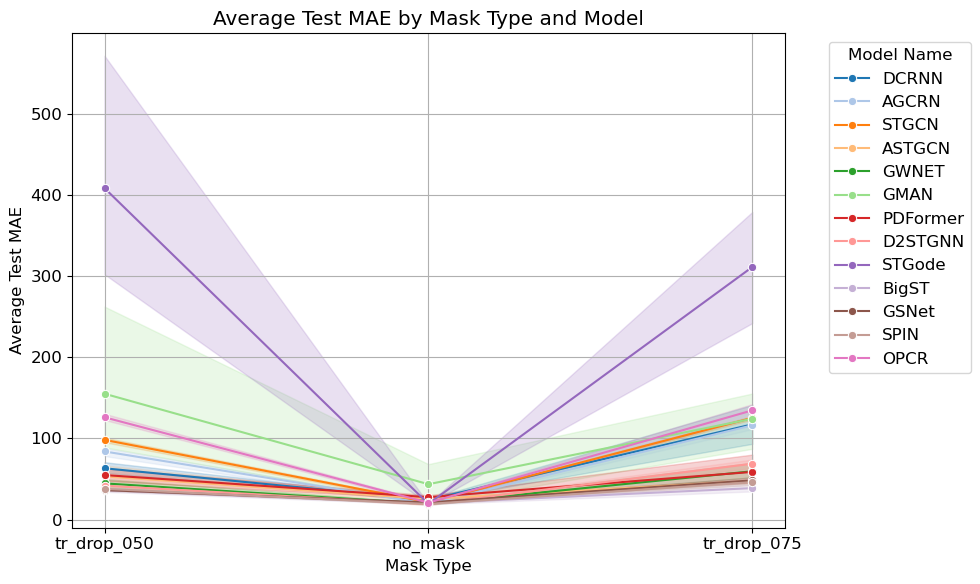

In [30]:
## create a line plot with the test_avg_mae on the y axis and the mask_name on the x axis and a line for each model_name, but only for the models that have all the mask_names available and have the test_avg_mae available for all mask_names
import matplotlib.pyplot as plt
import seaborn as sns

mask_dictionary = {
    'no_mask': 'no mask',
    'tr_drop_025': 'unseen-sensor 25%',
    'tr_drop_050': 'unseen-sensor 50%',
    'tr_drop_075': 'unseen-sensor 75%',
}



plt.figure(figsize=(10, 6))
# valid_models = runs.groupby('model_name').filter(lambda x: x['test_avg_mae'].notna().all() and set(x['mask_name']) == set(mask_dictionary.keys()))['model_name'].unique()
mask_runs = runs[runs['mask_name'].isin(['no_mask', 'tr_drop_035','tr_drop_050','tr_drop_075'])]
valid_models = mask_runs['model_name'].unique()
sns.lineplot(data=mask_runs[mask_runs['model_name'].isin(valid_models)], x='mask_name', y='test_avg_mae', hue='model_name', marker='o', palette=global_color_dict, hue_order =[model for model in global_ordering if model in valid_models],)
# plt.xticks(ticks=list(mask_dictionary.keys()), labels=[mask_dictionary[key] for key in mask_dictionary.keys()])
plt.xlabel('Mask Type')
plt.ylabel('Average Test MAE')
plt.title('Average Test MAE by Mask Type and Model')
plt.grid(True)
plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('img/mae_vs_mask_type.png', dpi=300, bbox_inches='tight')

In [12]:
sd_runs = runs[runs['withMD'] == 'True']
gba_runs = runs[runs['benchmark_GBA']]

grouped_sd_runs = sd_runs.groupby(['model_name', 'mask_name']).mean()
grouped_gba_runs = gba_runs.groupby(['model_name', 'mask_name']).mean()

mask_list = ['no_mask', 'tr_drop_025', 'tr_drop_050', 'tr_drop_075']#, 'point_missing_050', 'point_missing_075', 'point_missing_095']
baseline_list = ['AGCRN','ASTGCN', 'BigST', 'D2STGNN', 'DCRNN', 'GMAN', 'GSNet', 'GWNET', 'OPCR', 'PDFormer', 'SPIN', 'STGCN', 'STGode', 'DSGNN']

#table preamble 

print('\\begin{table*}[ht]')
print('\\centering')
# print('\\small')
print('\\begin{tabular}{|c|l|' + 'rrr|' * ( len(mask_list)) + '}')


mask_dictionary = {
    'no_mask': '0\%',
    'point_missing_050': '50\%',
    'point_missing_075': '75\%',
    'point_missing_095': '95\%',
    'tr_drop_025': '25\%',
    'tr_drop_050': '50\%',
    'tr_drop_075': '75\%',
}



# print latex table header with 2 + 3* num_mask list of columns and a header line with the mask names and a line with the baseline names
mask_name_latex = [f"\multicolumn{{3}}{{c|}}{{{mask_dictionary[mask]}}}" for mask in mask_list]
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f'Dataset & Baseline & {(" & ".join(mask_name_latex))} \\\\')

print(f' &  {"& MAE & RMSE & MAPE " * len(mask_list)} \\\\')
print('\\hline')


is_first_baseline = True

for baseline in baseline_list:
    if is_first_baseline:
            print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{SD}}', end='')
        
    print(f' & {baseline}', end='')
    for mask in mask_list:
        sd_mae = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in grouped_sd_runs.index else -1
        sd_rmse = grouped_sd_runs.loc[(baseline, mask), 'test_avg_rmse'] if (baseline, mask) in grouped_sd_runs.index else -1
        sd_mape = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mape'] * 100. if (baseline, mask) in grouped_sd_runs.index else -1
        
        print(f' & {sd_mae:.1f} & {sd_rmse:.1f} & {sd_mape:.1f}\\% ', end = "")
    print('\\\\')
    
    is_first_baseline = False
print('\\hline')
    

    
    
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\begin{tabular}{|c|l|rrr|rrr|rrr|rrr|}
Dataset & Baseline & \multicolumn{3}{c|}{0\%} & \multicolumn{3}{c|}{25\%} & \multicolumn{3}{c|}{50\%} & \multicolumn{3}{c|}{75\%} \\
 &  & MAE & RMSE & MAPE & MAE & RMSE & MAPE & MAE & RMSE & MAPE & MAE & RMSE & MAPE  \\
\hline
\multirow{14}{*}{SD} & AGCRN & 18.1 & 32.6 & 13.4\%  & 52.5 & 89.5 & 82.9\%  & 87.6 & 120.1 & 150.4\%  & 116.0 & 143.5 & 202.9\% \\
 & ASTGCN & 24.4 & 39.2 & 16.5\%  & 48.8 & 70.4 & 47.4\%  & 63.9 & 97.5 & 58.4\%  & 47.5 & 70.1 & 43.9\% \\
 & BigST & 18.7 & 30.9 & 13.0\%  & 33.7 & 55.2 & 22.9\%  & 37.5 & 56.3 & 32.3\%  & 38.7 & 56.3 & 37.8\% \\
 & D2STGNN & 17.3 & 29.1 & 11.7\%  & 31.0 & 51.0 & 24.1\%  & 41.6 & 65.2 & 36.7\%  & 68.7 & 100.6 & 73.7\% \\
 & DCRNN & 23.3 & 36.9 & 15.6\%  & 42.5 & 61.7 & 33.3\%  & 64.2 & 91.2 & 59.5\%  & 117.2 & 160.5 & 148.5\% \\
 & GMAN & 18.7 & 54.9 & 21.8\%  & 55.8 & 89.7 & 60.2\%  & 102.8 & 146.4 & 147.4\%  & 124.2 & 164.6 & 200.3\% \\
 & GSNet & 20.0 & 32.7 &

In [79]:

mask_list = ['point_missing_050', 'point_missing_075', 'point_missing_095']

#table preamble 

print('\\begin{table*}[ht]')
print('\\centering')
# print('\\small')
print('\\begin{tabular}{|c|l|' + 'rrr|' * ( len(mask_list)) + '}')


mask_dictionary = {
    'no_mask': '0\%',
    'point_missing_050': '50\%',
    'point_missing_075': '75\%',
    'point_missing_095': '95\%',
    'tr_drop_025': '25\%',
    'tr_drop_050': '50\%',
    'tr_drop_075': '75\%',
}



# print latex table header with 2 + 3* num_mask list of columns and a header line with the mask names and a line with the baseline names
mask_name_latex = [f"\multicolumn{{3}}{{c|}}{{{mask_dictionary[mask]}}}" for mask in mask_list]
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f'Dataset & Baseline & {(" & ".join(mask_name_latex))} \\\\')

print(f' &  {"& MAE & RMSE & MAPE " * len(mask_list)} \\\\')
print('\\hline')


is_first_baseline = True

for baseline in baseline_list:
    if is_first_baseline:
            print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{SD}}', end='')
        
    print(f' & {baseline}', end='')
    for mask in mask_list:
        sd_mae = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in grouped_sd_runs.index else -1
        sd_rmse = grouped_sd_runs.loc[(baseline, mask), 'test_avg_rmse'] if (baseline, mask) in grouped_sd_runs.index else -1
        sd_mape = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mape'] * 100. if (baseline, mask) in grouped_sd_runs.index else -1
        
        print(f' & {sd_mae:.1f} & {sd_rmse:.1f} & {sd_mape:.1f}\\% ', end = "")
    print('\\\\')
    
    is_first_baseline = False
print('\\hline')
    

    
    
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\begin{tabular}{|c|l|rrr|rrr|rrr|}
Dataset & Baseline & \multicolumn{3}{c|}{50\%} & \multicolumn{3}{c|}{75\%} & \multicolumn{3}{c|}{95\%} \\
 &  & MAE & RMSE & MAPE & MAE & RMSE & MAPE & MAE & RMSE & MAPE  \\
\hline
\multirow{14}{*}{SD} & AGCRN & 9.7 & 25.4 & 7.2\%  & 5.3 & 19.6 & 3.9\%  & 1.2 & 10.0 & 0.9\% \\
 & ASTGCN & 16.6 & 37.7 & 12.7\%  & 9.6 & 30.9 & 7.6\%  & 2.5 & 17.1 & 2.0\% \\
 & BigST & 10.1 & 24.3 & 7.2\%  & 5.3 & 18.4 & 3.7\%  & 1.2 & 9.2 & 0.8\% \\
 & D2STGNN & 9.1 & 22.3 & 6.1\%  & 4.9 & 17.4 & 3.3\%  & 1.2 & 9.4 & 0.8\% \\
 & DCRNN & 11.7 & 26.7 & 8.1\%  & 6.4 & 21.1 & 4.6\%  & 1.7 & 12.4 & 1.3\% \\
 & GMAN & 10.9 & 51.2 & 12.6\%  & 6.2 & 44.8 & 5.6\%  & 1.8 & 36.1 & 1.6\% \\
 & GSNet & 11.5 & 27.0 & 8.0\%  & 6.4 & 21.1 & 4.5\%  & 1.5 & 10.8 & 1.0\% \\
 & GWNET & 9.4 & 22.6 & 6.6\%  & 5.1 & 17.7 & 3.6\%  & 1.5 & 11.3 & 1.2\% \\
 & OPCR & 36.6 & 80.9 & 49.9\%  & 24.8 & 68.9 & 35.7\%  & 6.0 & 34.5 & 8.9\% \\
 & PDFormer & -1.0 & -1.0 & -1.

In [80]:
mask_list = ['no_mask', 'tr_drop_050', 'point_missing_075',]

#table preamble 

print('\\begin{table*}[ht]')
print('\\centering')
print("\caption{Performance results on the Greater Bay Area dataset for the no missing data, for 50\% unseen training sensors, and for 75\% point missing observations}")
# print('\\small')
print('\\begin{tabular}{|c|l|' + 'rrrr|' * ( len(mask_list)) + '}')


mask_dictionary = {
    'no_mask': '0\%',
    'point_missing_050': '50\%',
    'point_missing_075': 'Point Missing 75\%',
    'point_missing_095': '95\%',
    'tr_drop_025': '25\%',
    'tr_drop_050': 'Unseen 50\%',
    'tr_drop_075': '75\%',
}

mask_name_latex = [f"\multicolumn{{4}}{{c|}}{{{mask_dictionary[mask]}}}" for mask in mask_list]
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f'Dataset & Baseline & {(" & ".join(mask_name_latex))} \\\\')

print(f' &  {"& MAE & RMSE & MAPE & Ep." * len(mask_list)} \\\\')
print('\\hline')

is_first_baseline = True

for baseline in baseline_list:
    if is_first_baseline:
            print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{GBA}}', end='')
        
    print(f' & {baseline}', end='')
    for mask in mask_list:
        sd_mae = grouped_gba_runs.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in grouped_gba_runs.index else 404
        
        if sd_mae <= grouped_gba_runs.xs(mask, level='mask_name')['test_avg_mae'].min():
            sd_mae_str = f'\\textbf{{{sd_mae:.1f}}}'
        else:
            sd_mae_str = f'{sd_mae:.1f}'
            # if baseline == 'DSGNN': 
            #     sd_mae_str += f' (+{(sd_mae - grouped_gba_runs.xs(mask, level="mask_name")["test_avg_mae"].min()) / grouped_gba_runs.xs(mask, level="mask_name")["test_avg_mae"].min() * 100:.1f}\%)'
        
        sd_rmse = grouped_gba_runs.loc[(baseline, mask), 'test_avg_rmse'] if (baseline, mask) in grouped_gba_runs.index else 404
        if sd_rmse <= grouped_gba_runs.xs(mask, level='mask_name')['test_avg_rmse'].min():
            sd_rmse_str = f'\\textbf{{{sd_rmse:.1f}}}'
        else:
            sd_rmse_str = f'{sd_rmse:.1f}'
            # if baseline == 'DSGNN':
            #     sd_rmse_str += f' (+{(sd_rmse - grouped_gba_runs.xs(mask, level="mask_name")["test_avg_rmse"].min()) / grouped_gba_runs.xs(mask, level="mask_name")["test_avg_rmse"].min() * 100:.1f}\%)'
        sd_mape = grouped_gba_runs.loc[(baseline, mask), 'test_avg_mape'] * 100. if (baseline, mask) in grouped_gba_runs.index else 404 
        if sd_mape <= (grouped_gba_runs.xs(mask, level='mask_name')['test_avg_mape'] * 100).min():
            sd_mape_str = f'\\textbf{{{sd_mape:.1f}}}\\%'
        else:
            sd_mape_str = f'{sd_mape:.1f}\\%'
            # if baseline == 'DSGNN':
            #     sd_mape_str += f' (+{(sd_mape - (grouped_gba_runs.xs(mask, level="mask_name")["test_avg_mape"] * 100).min()):.1f}\%)'
            
        sd_epochs = grouped_gba_runs.loc[(baseline, mask), 'epochs'] if (baseline, mask) in grouped_gba_runs.index else -1
        
        
        
        if ((mask == 'tr_drop_075') or (mask == 'tr_drop_025')):
            print(f' &  &  &', end = "")
        else:
        
            print(f' & {sd_mae_str} & {sd_rmse_str} & {sd_mape_str} & {int(sd_epochs)}', end = "")
    print('\\\\')
    
    is_first_baseline = False
    
    
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\caption{Performance results on the Greater Bay Area dataset for the no missing data, for 50\% unseen training sensors, and for 75\% point missing observations}
\begin{tabular}{|c|l|rrrr|rrrr|rrrr|}
Dataset & Baseline & \multicolumn{4}{c|}{0\%} & \multicolumn{4}{c|}{Unseen 50\%} & \multicolumn{4}{c|}{Point Missing 75\%} \\
 &  & MAE & RMSE & MAPE & Ep.& MAE & RMSE & MAPE & Ep.& MAE & RMSE & MAPE & Ep. \\
\hline
\multirow{14}{*}{GBA} & AGCRN & \textbf{21.3} & 34.9 & \textbf{16.9}\% & 63 & 77.6 & 102.5 & 131.7\% & 35 & \textbf{6.1} & 20.0 & \textbf{5.0}\% & 63\\
 & ASTGCN & 26.7 & 43.7 & 26.0\% & 48 & 35.2 & 50.9 & 37.8\% & 37 & 9.6 & 28.2 & 9.8\% & 46\\
 & BigST & 22.4 & 35.3 & 20.1\% & 59 & 34.0 & 49.2 & 39.8\% & 41 & 6.7 & 21.1 & 6.2\% & 43\\
 & D2STGNN & 21.8 & 35.0 & 17.0\% & 11 & 41.8 & 61.7 & 43.2\% & 11 & 6.2 & \textbf{19.9} & 5.1\% & 11\\
 & DCRNN & 25.9 & 39.4 & 22.7\% & 24 & 61.4 & 85.4 & 47.1\% & 24 & 9.3 & 26.4 & 9.3\% & 24\\
 & GMAN & 84.8 & 11

In [2]:
import pandas as pd

df_tmp = pd.read_hdf('data/' + 'sd' + '/' + 'sd' + '_his_' + '2019' + '.h5')


<Axes: xlabel='Time'>

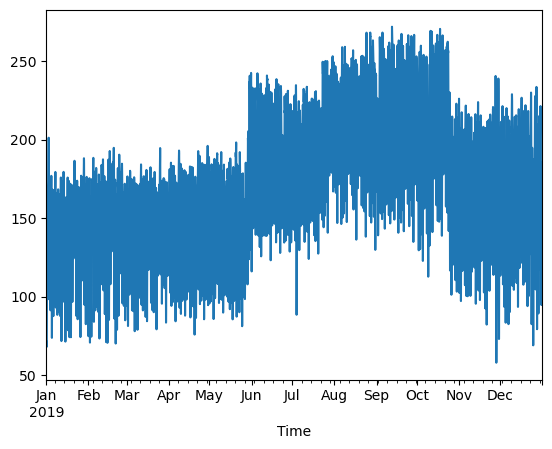

In [7]:
# smooth this timeline with a monthly lowpass filter with a window of 30 days and a gaussian kernel with a standard deviation of 10 days
df_tmp.iloc[:, 0].rolling(window=30, win_type='gaussian', center=True).mean(std=10).plot()

## Parameter Scaling 

/tmp/ipykernel_1969536/1889812327.py:29: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 8e6)
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


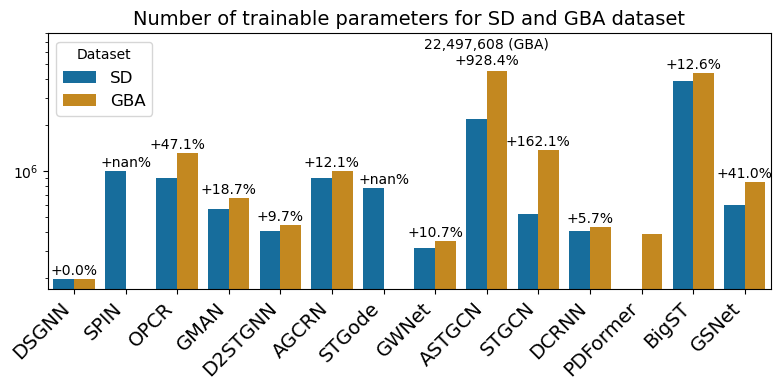

In [17]:
import pandas as pd

#set fontsize


df = pd.read_csv('model_parameters.csv')

astgcn_org_gba = int(df.loc[df['Baseline'] == 'ASTGCN', 'GBA'].values[0])
df.loc[df['Baseline'] == 'ASTGCN', 'GBA'] = 4_500_000

### columns: Baseline, SD, GBA

## make a figure as barplot with two bars per Baseline showing the numbers of SD and GBA paramters in a direct comparison
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 4))
sns.barplot(data=df.melt(id_vars='Baseline', var_name='Model', value_name
='Parameters'), x='Baseline', y='Parameters', hue='Model', palette='colorblind')
plt.title('Number of trainable parameters for SD and GBA dataset', fontsize=14)
# plt.ylabel('Number of Parameters (log)', fontsize=12)
plt.ylabel(None)
plt.yscale('log')
plt.xlabel(None)
plt.legend( title='Dataset', fontsize=12)#

##set the xticks labels in a 45° angle
plt.xticks(rotation=45, ha='right', fontsize=14)

plt.ylim(0, 8e6)

# write on top of each pair of bars the percentage difference between SD and GBA parameters
for index, row in df.iterrows():
    if row['Baseline'] == 'ASTGCN':
        sd_params = row['SD']
        gba_params = row['GBA']
        plt.text(index, max(sd_params, gba_params) * 1.1, f'{astgcn_org_gba:,} (GBA)\n+{(astgcn_org_gba - sd_params) / sd_params * 100:.1f}%', ha='center')
        # plt.bar(index - 0.2, sd_params, width=0.4, color='blue', alpha=0.5)
        # plt.bar(index + 0.2, gba_params, width=0.4, color='orange', alpha=0.5)
        
    else:
        sd_params = row['SD']
        gba_params = row['GBA']
        percentage_diff = (gba_params - sd_params) / sd_params * 100
        plt.text(index, max(sd_params, gba_params) * 1.06, f'+{percentage_diff:.1f}%', ha='center')
        
## cut the largest bar ASTGCN to make the plot more readable, but write the real number of parameters on top of the bar
# for index, row in df.iterrows():
#     if row['Baseline'] == 'ASTGCN':
#         sd_params = row['SD']
#         gba_params = row['GBA']
#         plt.text(index, max(sd_params, gba_params) * 1.06, f'{sd_params:,} (SD)\n{gba_params:,} (GBA)', ha='center')
#         plt.bar(index - 0.2, sd_params, width=0.4, color='blue', alpha=0.5)
#         plt.bar(index + 0.2, gba_params, width=0.4, color='orange', alpha=0.5)

plt.tight_layout()
# plt.show()

plt.savefig('img/model_parameters_comparison.png', dpi=300)

## Runtime comparison

```python

runs = api.runs("usc-infolab/deepstategnn", filters = {'$and': [{'tags': {"$in": ["withMD"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [None, "tr_drop_025", "tr_drop_050", "tr_drop_075"]}}]})


```

In [3]:
runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["benchmark_time"]}}, {'state': 'finished'}, {'config.mask_name': {"$in": [ "tr_drop_025", "tr_drop_050", "tr_drop_075"]}}]}), access_metadata = False)

100%|██████████| 78/78 [00:01<00:00, 71.00it/s]


In [4]:
is_H100 = runs.loc[:, 'gpu_type'] == 'NVIDIA H100 PCIe'
is_V100 = runs.loc[:, 'gpu_type'] == 'Tesla V100-SXM2-32GB'

model_filter = runs.loc[:, 'model_name'].isin(['DSGNN', 'BigST', 'GSNet', 'STGCN', 'GWNET', 'PDFormer'])
dataset_filter_SD = runs.loc[:, 'dataset'] == 'SD'

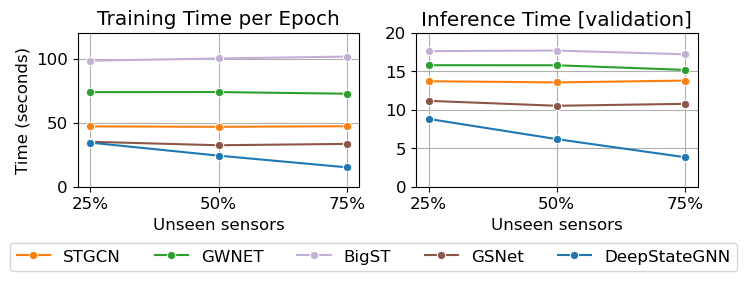

In [43]:
filtered_runs = runs.loc[model_filter & dataset_filter_SD ,:]
grouped_runs = filtered_runs.groupby(['model_name', filtered_runs.mask_name.fillna('None')]).mean()[['train_time_per_epoch', 'val_time']]

# grouped runs rename index value DSGNN into DeepStateGNN(our)
grouped_runs = grouped_runs.rename(index={'DSGNN': 'DeepStateGNN'})


## make a line plot in which each model_name group has its own line of the train_time_per_epoch column for all thesex values that are available in the mask_name

import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(8,2))


## make two plots left and rigfht to each other for val_time and train_time
ax = fig.add_subplot(1,2,1)


sns.lineplot(data=grouped_runs.reset_index(), x='mask_name', y='train_time_per_epoch', hue='model_name', marker='o', linestyle='-', ax = ax, legend=False, palette = global_color_dict, hue_order=[model for model in global_ordering if model in grouped_runs.reset_index().model_name.unique()])
plt.title('Training Time per Epoch')
plt.ylabel('Time (seconds)')
plt.xlabel('Unseen sensors')
# set x_tick labels to 0%, 25%, 50%, 75%
plt.xticks(ticks=range(len(grouped_runs.index.get_level_values('mask_name').unique())), labels=[ '25%', '50%', '75%'])
# plt.yscale('log')
plt.grid(True)
plt.ylim(0, 120)

## put the legend putside the plot on the right

ax = fig.add_subplot(1,2,2)
sns.lineplot(data=grouped_runs.reset_index(), x='mask_name', y='val_time', hue='model_name', marker='o', linestyle='-', ax = ax, palette = global_color_dict, hue_order=[model for model in global_ordering if model in grouped_runs.reset_index().model_name.unique()])
sns.move_legend(ax, "lower center", bbox_to_anchor=(-.15, -.6), ncol=5, title=None)

# plt.legend(title='Model Name',  loc='outside lower center')

# plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25),
        #   ncol=6, fancybox=True, shadow=True)
plt.ylabel(None)
plt.title('Inference Time [validation]')
plt.xlabel('Unseen sensors')

plt.xticks(ticks=range(len(grouped_runs.index.get_level_values('mask_name').unique())), labels=[ '25%', '50%', '75%'])
# plt.yscale('log')
plt.grid(True)
plt.ylim(0,20)



# fig.tight_layout()
# plt.tight_layout()
plt.savefig('img/training_time_per_epoch_H100.png', dpi=300, bbox_inches='tight')

In [25]:
filtered_runs

,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,static_prefilter_mode,gcn_layers,ablation_concat_queries,dsn_div_weight,...,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,train_mask,relative_train_time,relative_val_time
5,DSGNN,tr_drop_050,0.0,GBA,None,64.0,static_dsn,2.0,True,1.0,...,2.0,finished,[benchmark_time],None,24.982421,False,False,False,None,None
6,STGode,tr_drop_050,0.0,GBA,None,NaN,None,NaN,None,NaN,...,2.0,finished,[benchmark_time],None,98.026713,False,False,False,None,None
7,OPCR,tr_drop_050,0.0,GBA,None,NaN,None,NaN,None,NaN,...,2.0,finished,[benchmark_time],None,122.745767,False,False,False,None,None
8,GWNET,tr_drop_050,0.0,GBA,None,NaN,None,NaN,None,NaN,...,2.0,finished,[benchmark_time],None,82.017064,False,False,False,None,None
11,STGCN,tr_drop_050,0.0,GBA,None,NaN,None,NaN,None,NaN,...,2.0,finished,[benchmark_time],None,64.509104,False,False,False,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,STGCN,tr_drop_050,0.0,GBA,None,NaN,None,NaN,None,NaN,...,36.0,finished,[benchmark_GBA],None,103.266320,False,True,False,None,None
158,BigST,tr_drop_050,0.0,GBA,None,NaN,None,NaN,None,NaN,...,41.0,finished,[benchmark_GBA],None,127.850439,False,True,False,None,None
161,BigST,no_mask,0.0,GBA,None,NaN,None,NaN,None,NaN,...,92.0,finished,[benchmark_GBA],None,63.377774,False,True,False,None,None
162,STGCN,no_mask,0.0,GBA,None,NaN,None,NaN,None,NaN,...,100.0,finished,[benchmark_GBA],None,54.150105,False,True,False,None,None


In [37]:
runs

,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,static_prefilter_mode,gcn_layers,ablation_concat_queries,dsn_div_weight,...,test_avg_rmse,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,train_mask
0,STGCN,tr_drop_075,0.0,GBA,None,NaN,None,NaN,None,NaN,...,79.425504,STGCN_GBA_2019_STGCN_tr_drop_075_0_2026-04-23 ...,2.0,finished,[benchmark_time],None,62.126891,False,False,False
1,ASTGCN,tr_drop_075,0.0,GBA,None,NaN,None,NaN,None,NaN,...,57.228466,ASTGCN_GBA_2019_ASTGCN_tr_drop_075_0_2026-04-2...,2.0,finished,[benchmark_time],None,110.433951,False,False,False
2,AGCRN,tr_drop_075,0.0,GBA,None,NaN,None,NaN,None,NaN,...,136.893987,AGCRN_GBA_2019_AGCRN_tr_drop_075_0_2026-04-23 ...,2.0,finished,[benchmark_time],None,96.715264,False,False,False
3,GSNet,tr_drop_075,0.0,GBA,None,NaN,None,NaN,None,NaN,...,57.705712,GSNet_GBA_2019_GSNet_tr_drop_075_0_2026-04-23 ...,2.0,finished,[benchmark_time],None,51.857133,False,False,False
4,BigST,tr_drop_075,0.0,GBA,None,NaN,None,NaN,None,NaN,...,49.334374,BigST_GBA_2019_BigST_tr_drop_075_0_2026-04-23 ...,2.0,finished,[benchmark_time],None,70.260361,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,ASTGCN,no_mask,0.0,GBA,None,NaN,None,NaN,None,NaN,...,43.689047,ASTGCN_GBA_2019_ASTGCN_nomask_2026-03-16 09:04,48.0,finished,[benchmark_GBA],None,104.929562,False,True,False
161,BigST,no_mask,0.0,GBA,None,NaN,None,NaN,None,NaN,...,34.662688,BigST_GBA_2019_BigST_nomask_2026-03-16 09:04,92.0,finished,[benchmark_GBA],None,63.377774,False,True,False
162,STGCN,no_mask,0.0,GBA,None,NaN,None,NaN,None,NaN,...,38.043997,STGCN_GBA_2019_STGCN_nomask_2026-03-16 09:04,100.0,finished,[benchmark_GBA],None,54.150105,False,True,False
163,DCRNN,no_mask,0.0,GBA,None,NaN,None,NaN,None,NaN,...,39.808586,DCRNN_GBA_2019_DCRNN_nomask_2026-03-16 09:04,24.0,finished,[benchmark_GBA],None,241.164734,False,True,False


In [11]:
joined_frame = runs[runs.dataset == 'SD'].set_index(['model_name', 'mask_name']).join(runs[runs.dataset == 'GBA'].set_index(['model_name', 'mask_name']), on = ['model_name', 'mask_name'], lsuffix = '_SD', rsuffix = '_GBA')

joined_frame['ratio_train'] = joined_frame.apply(lambda row: row['train_time_per_epoch_GBA'] / row['train_time_per_epoch_SD'] if (row['train_time_per_epoch_SD'] > 0 and row['train_time_per_epoch_GBA'] > 0) else None, axis=1)

joined_frame['ratio_val'] = joined_frame.apply(lambda row: row['val_time_GBA'] / row['val_time_SD'] if (row['val_time_SD'] > 0 and row['val_time_GBA'] > 0) else None, axis=1)

joined_frame[['ratio_train', 'ratio_val']]

,,ratio_train,ratio_val
model_name,mask_name,,
SPIN,tr_drop_075,NaN,NaN
DSGNN,tr_drop_075,3.079917,3.212083
STGode,tr_drop_075,4.360430,4.738458
OPCR,tr_drop_075,4.667885,4.774772
GWNET,tr_drop_075,5.510505,5.411025
GMAN,tr_drop_075,NaN,NaN
D2STGNN,tr_drop_075,11.167440,10.517967
DCRNN,tr_drop_075,3.380343,3.648268
STGCN,tr_drop_075,4.305961,4.498333


In [35]:
filtered_runs[filtered_runs.dataset == 'SD'].join(filtered_runs[filtered_runs.dataset == 'GBA'], on=['model_name', 'mask_name'], lsuffix='_SD', rsuffix='_GBA')

ValueError: len(left_on) must equal the number of levels in the index of "right"

In [12]:
filtered_runs[filtered_runs.dataset == 'SD'].set_index(['model_name', 'mask_name']).join(filtered_runs[filtered_runs.dataset == 'GBA'].set_index(['model_name', 'mask_name']), on=['model_name', 'mask_name'], lsuffix='_SD', rsuffix='_GBA').apply(lambda row: row['train_time_per_epoch_SD'] / row['train_time_per_epoch_GBA'], axis=1)

NameError: name 'filtered_runs' is not defined

/tmp/ipykernel_1308687/4211786490.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_runs.loc[:, 'relative_train_time'] = filtered_runs.apply(lambda row: row['train_time_per_epoch'] / grouped_runs.loc[(row['model_name'], row['mask_name']), 'train_time_per_epoch'] if (row['model_name'], row['mask_name']) in grouped_runs.index else None, axis=1)
/tmp/ipykernel_1308687/4211786490.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_runs.loc[:, 'relative_val_time'] = filtered_runs.apply(lambda

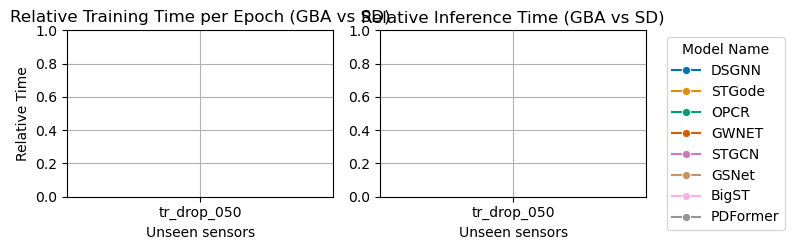

In [20]:
## group by model_name and mask_name and then there will be two lines for the SD dataset and the GBA. Now divide the train_time_per_epoch and val_time of the GBA by the corresponding values of the SD to get a relative training and inference time compared to the SD dataset. Then plot this relative time in a line plot with the same x axis and hue as before. This will show how much slower or faster the training and inference time is on the GBA compared to the SD dataset for each model and mask type.

filtered_runs.loc[:, 'relative_train_time'] = filtered_runs.apply(lambda row: row['train_time_per_epoch'] / grouped_runs.loc[(row['model_name'], row['mask_name']), 'train_time_per_epoch'] if (row['model_name'], row['mask_name']) in grouped_runs.index else None, axis=1)

filtered_runs.loc[:, 'relative_val_time'] = filtered_runs.apply(lambda row: row['val_time'] / grouped_runs.loc[(row['model_name'], row['mask_name']), 'val_time'] if (row['model_name'], row['mask_name']) in grouped_runs.index else None, axis=1)

fig = plt.figure(figsize=(8, 2.6))

ax = fig.add_subplot(1,2,1)
sns.lineplot(data=filtered_runs.reset_index(), x='mask_name', y='relative_train_time', hue='model_name', marker='o', linestyle='-', ax = ax, legend=False, palette = 'colorblind')
plt.title('Relative Training Time per Epoch (GBA vs SD)')
plt.ylabel('Relative Time')
plt.xlabel('Unseen sensors')
# plt.xticks(ticks=range(len(grouped_runs.index.get_level_values('mask_name').unique())), labels=['0%', '25%', '50%', '75%'])
plt.grid(True)
ax = fig.add_subplot(1,2,2)
sns.lineplot(data=filtered_runs.reset_index(), x='mask_name', y='relative_val_time', hue='model_name', marker='o', linestyle='-', ax = ax, palette = 'colorblind')
plt.legend(title='Model Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel(None)
plt.title('Relative Inference Time (GBA vs SD)')
plt.xlabel('Unseen sensors')
# plt.xticks(ticks=range(len(grouped_runs.index.get_level_values('mask_name').unique())), labels=['0%', '25%', '50%', '75%'])
plt.grid(True)
plt.tight_layout()
# plt.savefig('img/relative_training_time_H100.png', dpi=300)

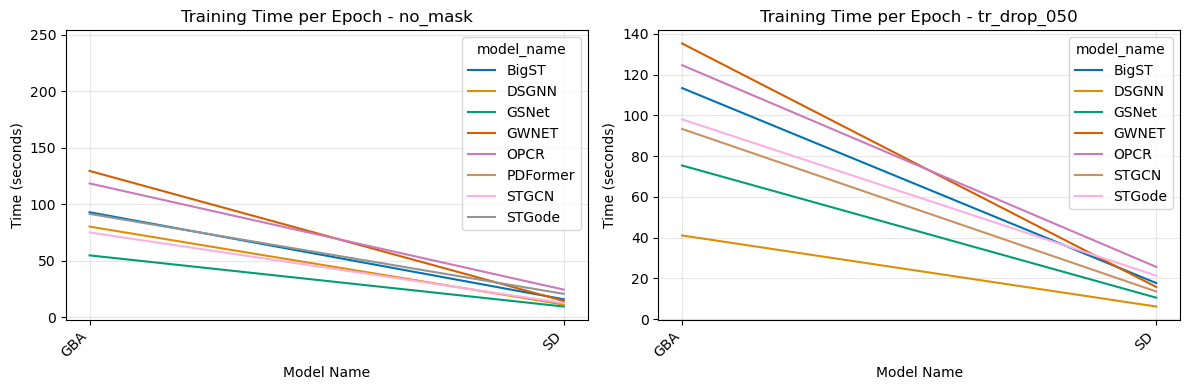

In [17]:
filtered_runs = runs.loc[~is_H100 & model_filter & (runs.mask_name.isin(['no_mask', 'tr_drop_050'])),:]

grouped_runs = filtered_runs.groupby(['mask_name', 'model_name', 'dataset']).mean()[['train_time_per_epoch', 'val_time']]

import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(12, 4))

for idx, mask in enumerate(['no_mask', 'tr_drop_050']):
    ax = fig.add_subplot(1, 2, idx + 1)
    mask_data = grouped_runs.xs(mask, level='mask_name').reset_index()
    
    # sns.barplot(data=mask_data, x='model_name', y='train_time_per_epoch', hue='dataset', ax=ax, palette='colorblind')
    
    sns.lineplot(data=mask_data, x='dataset', y='val_time', hue='model_name', ax=ax, palette='colorblind', legend=True)
    
    ax.set_title(f'Training Time per Epoch - {mask}')
    ax.set_ylabel('Time (seconds)')
    ax.set_xlabel('Model Name')
    ax.tick_params(axis='x', rotation=45)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()


In [16]:
grouped_runs

train_time_per_epoch    val_time
mask_name   model_name dataset                                  
no_mask     BigST      GBA                716.580106  122.576723
                       SD                 197.100476   30.778218
            DSGNN      GBA                386.511977   90.248605
                       SD                  95.159402   20.346193
            GSNet      GBA                237.807214   76.235509
                       SD                  48.851220   14.876715
            GWNET      GBA                770.106049  146.453300
                       SD                 134.741926   25.780211
            OPCR       SD                 201.494092   40.198615
            STGCN      GBA                333.667951   95.565561
                       SD                  80.054856   21.936082
            STGode     SD                 223.066319   38.204293
tr_drop_050 BigST      GBA                745.981665  127.340333
                       SD                 205.030961   32.218942
            DSGNN      GBA                198.338738   46.453418
                       SD                  52.270069   11.422473
            GSNet      GBA                257.541306   82.583694
            GWNET      GBA                804.563301  153.018352
                       SD                 140.448175   27.526805
            OPCR       SD                 205.062579   41.795249
            STGCN      GBA                358.529008  102.948644
                       SD                  84.985882   23.998160
            STGode     SD                 227.839629   40.083940

## Ablation Studies

In [82]:
ablation_dsn_runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_dsn_embed_dim"]}}, {'state': 'finished'}]}))


100%|██████████| 21/21 [00:14<00:00,  1.46it/s]


In [83]:
## max min scale the test_avg_mae column for each model_name and mask_name combination and plot the results in a barplot
ablation_dsn_runs['test_avg_mae_scaled'] = ablation_dsn_runs.groupby(['model_name', 'mask_name'])['test_avg_mae'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

In [ ]:
# multiply those test_avg_mae values that are part of the mask_name = point_missing_075 by 4
# ablation_dsn_runs.loc[ablation_dsn_runs['mask_name'] == 'point_missing_075', 'test_avg_mae'] *= 4

<Axes: xlabel='mask_name', ylabel='test_avg_mae'>

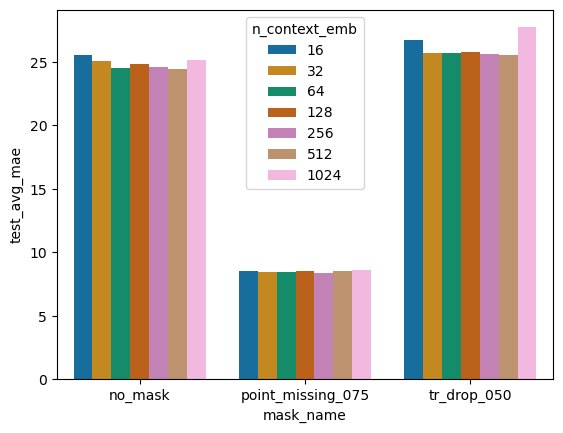

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.barplot(data=ablation_dsn_runs, x='mask_name', y='test_avg_mae', hue='n_context_emb', palette='colorblind')

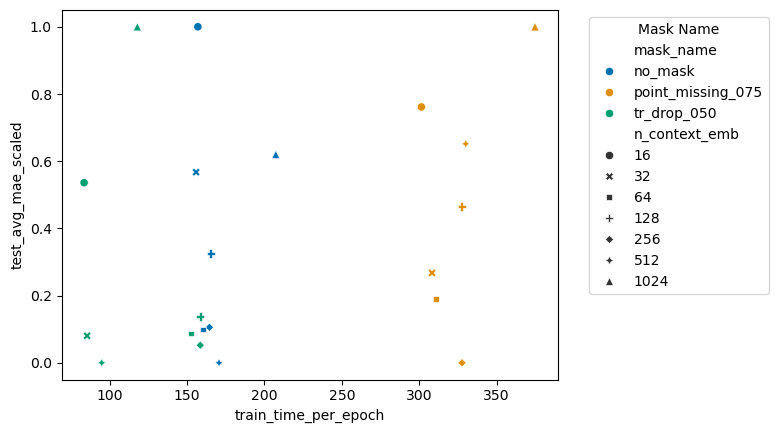

In [86]:
sns.scatterplot(data=ablation_dsn_runs, x='train_time_per_epoch', y='test_avg_mae_scaled', hue='mask_name', palette='colorblind', legend=True, style='n_context_emb')

plt.legend(title='Mask Name', bbox_to_anchor=(1.05, 1), loc='upper left')

## Ablation GCN Layers

In [33]:
ablation_gcn_runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_gcn_layers"]}}, {'state': 'finished'}]}))
ablation_gcn_runs

100%|██████████| 27/27 [00:19<00:00,  1.37it/s]


,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,n_hid,static_prefilter_mode,gcn_layers,ablation_concat_queries,...,test_avg_rmse,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,train_mask
0,DSGNN,tr_drop_050,0,SD,Tesla V100-SXM2-32GB,32,16,static_dsn,4,True,...,43.842175,DSGNN_SD_2019_DSGNN_tr_drop_050_0_2026-04-30 1...,100,finished,[ablation_gcn_layers],None,8.074314,False,False,False
1,DSGNN,no_mask,0,SD,Tesla V100-SXM2-32GB,32,16,static_dsn,4,True,...,35.962847,DSGNN_SD_2019_DSGNN_nomask_2026-04-30 13:37,100,finished,[ablation_gcn_layers],None,13.612033,False,False,False
2,DSGNN,point_missing_075,0,SD,Tesla V100-SXM2-32GB,32,16,static_dsn,4,True,...,23.795255,DSGNN_SD_2019_DSGNN_point_missing_075_0_2026-0...,100,finished,[ablation_gcn_layers],None,14.624475,False,False,False
3,DSGNN,point_missing_075,0,GBA,Tesla V100-SXM2-32GB,64,16,static_dsn,3,True,...,24.714517,DSGNN_GBA_2019_DSGNN_point_missing_075_0_2026-...,94,finished,[ablation_gcn_layers],None,79.023162,False,False,False
4,DSGNN,point_missing_075,0,GBA,Tesla V100-SXM2-32GB,64,16,static_dsn,2,True,...,24.797032,DSGNN_GBA_2019_DSGNN_point_missing_075_0_2026-...,93,finished,[ablation_gcn_layers],None,79.816757,False,False,False
5,DSGNN,point_missing_075,0,GBA,Tesla V100-SXM2-32GB,64,16,static_dsn,1,True,...,24.809554,DSGNN_GBA_2019_DSGNN_point_missing_075_0_2026-...,94,finished,[ablation_gcn_layers],None,79.804175,False,False,False
6,DSGNN,point_missing_075,0,GBA,Tesla V100-SXM2-32GB,64,16,static_dsn,0,True,...,25.495565,DSGNN_GBA_2019_DSGNN_point_missing_075_0_2026-...,97,finished,[ablation_gcn_layers],None,77.352471,False,False,False
7,DSGNN,tr_drop_050,0,GBA,Tesla V100-SXM2-32GB,64,16,static_dsn,3,True,...,39.681604,DSGNN_GBA_2019_DSGNN_tr_drop_050_0_2026-04-07 ...,100,finished,[ablation_gcn_layers],None,41.255301,False,False,False
8,DSGNN,tr_drop_050,0,GBA,Tesla V100-SXM2-32GB,64,16,static_dsn,2,True,...,39.275858,DSGNN_GBA_2019_DSGNN_tr_drop_050_0_2026-04-07 ...,100,finished,[ablation_gcn_layers],None,41.208031,False,False,False
9,DSGNN,tr_drop_050,0,GBA,Tesla V100-SXM2-32GB,64,16,static_dsn,0,True,...,41.115675,DSGNN_GBA_2019_DSGNN_tr_drop_050_0_2026-04-07 ...,100,finished,[ablation_gcn_layers],None,41.138422,False,False,False


In [34]:
ablation_gcn_runs['test_avg_mae_scaled'] = ablation_gcn_runs.groupby(['model_name', 'mask_name'])['test_avg_mae'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))



<Axes: xlabel='dataset', ylabel='test_avg_mae'>

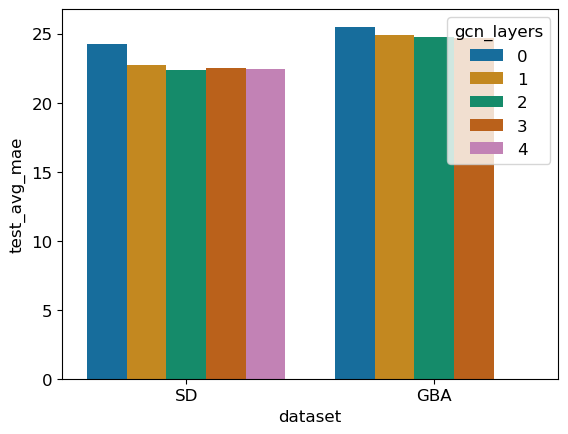

In [35]:
sns.barplot(data=ablation_gcn_runs[ablation_gcn_runs.mask_name == 'no_mask'], x='dataset', y='test_avg_mae', hue='gcn_layers', palette='colorblind', order=['SD', 'GBA'])

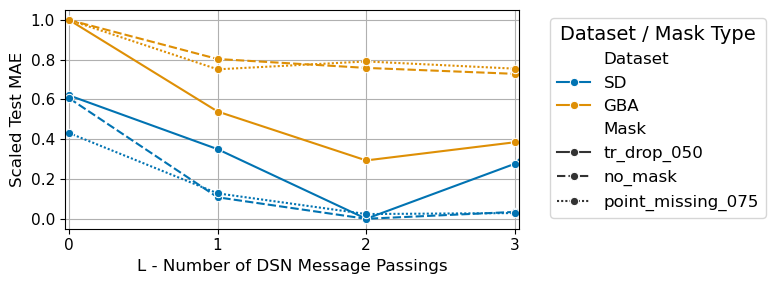

In [36]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(8, 3))

ax = fig.add_subplot(1, 1, 1)

ablation_gcn_runs = ablation_gcn_runs.rename(columns ={'mask_name': 'Mask', 'dataset': 'Dataset'} )


sns.lineplot(data=ablation_gcn_runs, style='Mask', x='gcn_layers', y='test_avg_mae_scaled', hue='Dataset', palette='colorblind', marker='o', legend='brief', ax = ax)
ax.set_title(None)
ax.set_xlabel('L - Number of DSN Message Passings', fontsize = 12)
ax.set_ylabel('Scaled Test MAE', fontsize = 12)
plt.xticks(fontsize = 11)
plt.yticks(fontsize = 11)
ax.grid(True)
plt.legend(title='Dataset / Mask Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=14)
ax.set_xticks([0,1,2,3])
ax.set_xlim(-.03,3.03)
plt.tight_layout()
plt.savefig('img/ablation_gcn_layers.png', dpi=300)

In [23]:
ablation_concat_runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_concat_queries"]}}, {'state': 'finished'}]}))

100%|██████████| 6/6 [00:04<00:00,  1.49it/s]


In [66]:
ablation_concat_runs

,model_name,mask_name,mask_iter,dataset,gpu_type,n_context_emb,static_prefilter_mode,gcn_layers,ablation_concat_queries,dsn_div_weight,...,name,epochs,state,tags,val_loss,val_time,withMD,benchmark_GBA,train_mask,test_avg_mae_scaled
0,DSGNN,point_missing_075,0,SD,NVIDIA H100 PCIe,64,static_dsn,3,False,0.001,...,DSGNN_SD_2019_DSGNN_point_missing_075_0_2026-0...,100,finished,[ablation_concat_queries],None,11.101671,False,False,False,1.0
1,DSGNN,point_missing_075,0,SD,Tesla V100-SXM2-32GB,64,static_dsn,3,True,0.001,...,DSGNN_SD_2019_DSGNN_point_missing_075_0_2026-0...,100,finished,[ablation_concat_queries],None,17.797652,False,False,False,0.0
2,DSGNN,tr_drop_050,0,SD,Tesla V100-SXM2-32GB,64,static_dsn,3,False,0.001,...,DSGNN_SD_2019_DSGNN_tr_drop_050_0_2026-03-31 2...,100,finished,[ablation_concat_queries],None,10.517475,False,False,False,1.0
3,DSGNN,tr_drop_050,0,SD,Tesla V100-SXM2-32GB,64,static_dsn,3,True,0.001,...,DSGNN_SD_2019_DSGNN_tr_drop_050_0_2026-03-31 2...,100,finished,[ablation_concat_queries],None,10.258581,False,False,False,0.0
4,DSGNN,no_mask,0,SD,NVIDIA H100 PCIe,64,static_dsn,3,False,0.001,...,DSGNN_SD_2019_DSGNN_nomask_2026-03-31 20:49,100,finished,[ablation_concat_queries],None,9.766312,False,False,False,1.0
5,DSGNN,no_mask,0,SD,NVIDIA H100 PCIe,64,static_dsn,3,True,0.001,...,DSGNN_SD_2019_DSGNN_nomask_2026-03-31 20:47,100,finished,[ablation_concat_queries],None,9.754885,False,False,False,0.0


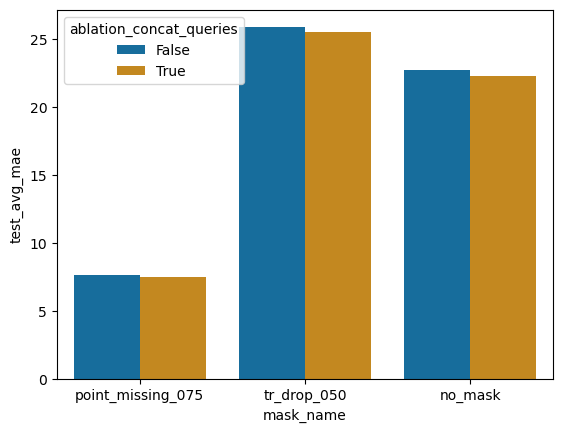

In [24]:
ablation_concat_runs['test_avg_mae_scaled'] = ablation_concat_runs.groupby(['model_name', 'mask_name'])['test_avg_mae'].transform(lambda x: (x - x.min()) / (x.max() - x.min()))

sns.barplot(data=ablation_concat_runs, x='mask_name', y='test_avg_mae', hue='ablation_concat_queries', palette='colorblind')

plt.savefig('img/concat_queries.png', dpi = 300)

## Ablation static_mode

In [4]:
ablation_fixed_context_runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_static_prefilter_mode"]}}, {'state': 'finished'}]}),  access_metadata = False)
ablation_fixed_context_runs.columns

100%|██████████| 40/40 [00:00<00:00, 22671.91it/s]


Index(['model_name', 'mask_name', 'mask_iter', 'dataset', 'gpu_type',
       'n_context_emb', 'n_hid', 'static_prefilter_mode', 'gcn_layers',
       'ablation_concat_queries', 'dsn_div_weight', 'dsn_div_margin',
       'dropout', 'n_context', 'test_avg_mae',
       'test_available_sensors_avg_mae', 'test_unavailable_sensors_avg_mae',
       'train_time_per_epoch', 'test_avg_mape', 'test_avg_rmse', 'name',
       'epochs', 'state', 'tags', 'val_loss', 'val_time', 'withMD',
       'benchmark_GBA', 'train_mask'],
      dtype='object')

In [7]:
ablation_fixed_context_runs = ablation_fixed_context_runs.groupby(['mask_name', 'static_prefilter_mode', 'n_context'])[['test_avg_mae', 'test_available_sensors_avg_mae', 'test_unavailable_sensors_avg_mae', 'train_time_per_epoch', 'val_time']].mean()

In [12]:
ablation_fixed_context_runs

test_avg_mae  \
mask_name         static_prefilter_mode n_context                 
no_mask           fixed                 50            24.567796   
                                        100           23.504511   
                                        200           22.386436   
                                        350           21.283917   
                  identity              64            22.170977   
                  none                  50            25.313227   
                                        100           24.926527   
                                        200           24.520616   
                                        350           24.872113   
                  static_dsn            64            22.924472   
point_missing_075 fixed                 50             8.349364   
                                        100            8.689603   
                                        200            8.192079   
                                        350            7.016790   
                  identity              64             7.376804   
                  none                  50             8.433984   
                                        100            8.179265   
                                        200            8.284786   
                                        350            8.294543   
                  static_dsn            64             7.768051   
tr_drop_050       fixed                 50            37.757806   
                                        100           39.427740   
                                        200           42.742013   
                                        350           41.682095   
                  identity              64            95.377392   
                  none                  50            26.743078   
                                        100           26.647833   
                                        200           27.636631   
                                        350           27.629840   
                  static_dsn            64            24.822192   
tr_drop_075       fixed                 50            47.652403   
                                        100           52.197127   
                                        200           47.249973   
                                        350           53.178489   
                  identity              64            98.904498   
                  none                  50            32.326288   
                                        100           35.291103   
                                        200           33.888247   
                                        350           38.642439   
                  static_dsn            64            29.090584   

                                                   test_available_sensors_avg_mae  \
mask_name         static_prefilter_mode n_context                                   
no_mask           fixed                 50                                    NaN   
                                        100                                   NaN   
                                        200                                   NaN   
                                        350                                   NaN   
                  identity              64                                    NaN   
                  none                  50                                    NaN   
                                        100                                   NaN   
                                        200                                   NaN   
                                        350                                   NaN   
                  static_dsn            64                                    NaN   
point_missing_075 fixed                 50                                    NaN   
                                        100                                   NaN   
                                        200   

In [25]:
# print Latex table header


print('\\begin{table*}[ht]')
print('\\centering')
# print('\\small')
print('\\begin{tabular}{|l|' + 'r|r|rrrr|rrrr|')



# print latex table header with 2 + 3* num_mask list of columns and a header line with the mask names and a line with the baseline names
# print(f'&&\multicolumn{{12}}{{c|}}{{Unseen Sensors}}&\multicolumn{{9}}{{c|}}{{point missing Sensors}} \\\\')
print(f' & Identity & DeepStateGNN & \multicolumn{{4}}{{c|}}{{Fixed}} & \multicolumn{{4}}{{c|}}{{Dynamic}} \\\\')
print(f'Number of DSNs: & |$\\mathcal{{S}}|$| & 56 & 50 & 100 & 200 & 300 & 50 & 100 & 200 & 300 \\\\')
print('\\hline')


# is_first_baseline = True

# for baseline in baseline_list:
#     if is_first_baseline:
#             print(f'\\multirow{{{len(baseline_list)}}}{{*}}{{SD}}', end='')
        
#     print(f' & {baseline}', end='')
#     for mask in mask_list:
#         sd_mae = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mae'] if (baseline, mask) in grouped_sd_runs.index else -1
#         sd_rmse = grouped_sd_runs.loc[(baseline, mask), 'test_avg_rmse'] if (baseline, mask) in grouped_sd_runs.index else -1
#         sd_mape = grouped_sd_runs.loc[(baseline, mask), 'test_avg_mape'] * 100. if (baseline, mask) in grouped_sd_runs.index else -1
        
#         print(f' & {sd_mae:.1f} & {sd_rmse:.1f} & {sd_mape:.1f}\\% ', end = "")
#     print('\\\\')
    
#     is_first_baseline = False
# print('\\hline')
    

mask_dictionary = {
    'no_mask': 'No Mask',
    'point_missing_075': '75\% point missing',
    'tr_drop_050': '50\% unseen sensors',
    'tr_drop_075': '75\% unseen sensors',
}
    
    


for mask in ablation_fixed_context_runs.index.get_level_values('mask_name').unique():
    mask_data = ablation_fixed_context_runs.xs(mask, level='mask_name')
    
    identity_mae = mask_data.xs(('identity', 64), level=['static_prefilter_mode', 'n_context'])['test_avg_mae'].values[0] 
    
    deepstate_mae = mask_data.xs(('static_dsn', 64), level=['static_prefilter_mode', 'n_context'])['test_avg_mae'].values[0]
    
    print(f'{mask_dictionary[mask]} & {identity_mae:.1f} & {deepstate_mae:.1f} ', end='')
    for mode in ['fixed', 'none']:
        for n_context in [50, 100, 200, 350]:
            mae = mask_data.xs((mode, n_context), level=['static_prefilter_mode', 'n_context'])['test_avg_mae'].values[0]
            print(f'& {mae:.1f} ', end='')
            
    print('\\\\')
        

        
print('\\end{tabular}')
print('\\end{table*}')

\begin{table*}[ht]
\centering
\begin{tabular}{|l|r|r|rrrr|rrrr|
 & Identity & DeepStateGNN & \multicolumn{4}{c|}{Fixed} & \multicolumn{4}{c|}{Dynamic} \\
Number of DSNs: & |$\mathcal{S}|$| & 56 & 50 & 100 & 200 & 300 & 50 & 100 & 200 & 300 \\
\hline
No Mask & 22.2 & 22.9 & 24.6 & 23.5 & 22.4 & 21.3 & 25.3 & 24.9 & 24.5 & 24.9 \\
75\% point missing & 7.4 & 7.8 & 8.3 & 8.7 & 8.2 & 7.0 & 8.4 & 8.2 & 8.3 & 8.3 \\
50\% unseen sensors & 95.4 & 24.8 & 37.8 & 39.4 & 42.7 & 41.7 & 26.7 & 26.6 & 27.6 & 27.6 \\
75\% unseen sensors & 98.9 & 29.1 & 47.7 & 52.2 & 47.2 & 53.2 & 32.3 & 35.3 & 33.9 & 38.6 \\
\end{tabular}
\end{table*}


In [18]:
mask_data.xs(('static_dsn', 64), level=['static_prefilter_mode', 'n_context'])['test_avg_mae'].values[0]

22.924471855163578

## Ablation hidden dim

In [43]:
runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_hidden_dim"]}}, {'state': 'finished'}]}))    

100%|██████████| 21/21 [00:17<00:00,  1.23it/s]


/tmp/ipykernel_2488477/3965117658.py:30: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  l2 = sns.lineplot(
/tmp/ipykernel_2488477/3965117658.py:35: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  l3 = sns.lineplot(
/tmp/ipykernel_2488477/3965117658.py:61: UserWarning: Tight layout not applied. tight_layout cannot make axes width small enough to accommodate all axes decorations
  plt.tight_layout()


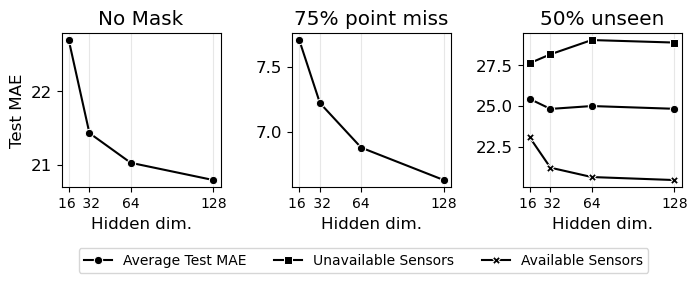

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(8, 2))

# make a gridspec with 2x4
# gs = fig.add_gridspec(2, 4, wspace=0.4)


mask_dictionary = {
    'no_mask': 'No Mask',
    'point_missing_075': '75% point miss',
    'tr_drop_050': '50% unseen',
    'tr_drop_075': '75% unseen',
}

mask_i = 0
for mask in ['no_mask', 'point_missing_075', 'tr_drop_050']:
    mask_data = runs[runs.mask_name == mask].groupby('n_hid').mean()
    # ax = fig.add_subplot(gs[0, mask_i]) 
    ax = fig.add_subplot(1,3, mask_i + 1)
     
    
    sns.lineplot(
        data=mask_data, x='n_hid', y='test_avg_mae',
        marker='o', ax=ax, legend=mask_i == 2, label='Average Test MAE', color='k'
    )
    
    if 'tr' in mask:
        l2 = sns.lineplot(
            data=mask_data, x='n_hid', y='test_unavailable_sensors_avg_mae',
            palette=['k'],
            marker='s', ax=ax, legend=mask_i == 2, label='Unavailable Sensors', color='k'
        )
        l3 = sns.lineplot(
            data=mask_data, x='n_hid', y='test_available_sensors_avg_mae',
            palette=['k'],
            marker='X', ax=ax, legend=mask_i == 2, label='Available Sensors', color='k'
        )
    
    ax.set_xticks([16, 32, 64, 128])
    ax.set_xticklabels(['16 ', ' 32', '64', '128'], fontsize=10)
    ax.set_title(mask_dictionary[mask])
    
    if mask_i == 0:
        ax.set_ylabel('Test MAE')
    else:
        ax.set_ylabel(None)
    ax.set_xlabel('Hidden dim.')
    ax.grid(axis='x', alpha=0.3)

    if mask_i == 2:
        # handles, labels = ax.get_legend_handles_labels()
        # legend_ax = fig.add_subplot(gs[1, :])
        # legend_ax.legend(handles = [l1,l2,l3])#, ['a', 'b', 'c'], loc='center', ncol=3, fancybox=True, shadow=True)
        # legend_ax.axis('off')
        sns.move_legend(ax, "upper center", bbox_to_anchor=(-1., -0.35), ncol=3, fontsize=10, title_fontsize=12)
    
    mask_i += 1
plt.subplots_adjust(wspace=.45)
plt.tight_layout()
plt.savefig('img/ablation_hidden_dim_facet.png', dpi=300, bbox_inches='tight')

<Axes: xlabel='n_hid', ylabel='train_time_per_epoch'>

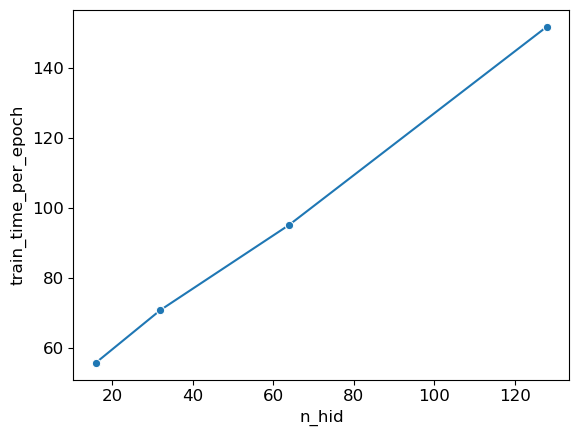

In [17]:
sns.lineplot(data=runs[runs.mask_name == 'no_mask'].groupby('n_hid').mean(), x='n_hid', y='train_time_per_epoch', marker='o')

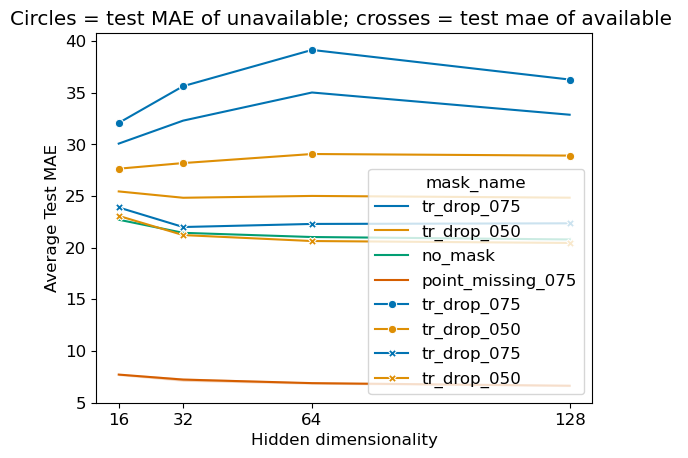

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.lineplot(runs.set_index('mask_name').loc[["tr_drop_075", "tr_drop_050", 'no_mask', 'point_missing_075'],:].reset_index(), x="n_hid", y="test_avg_mae", hue='mask_name', palette = 'colorblind')
# sns.lineplot(runs, x="n_hid", y="test_avg_mae", hue='mask_name')

sns.lineplot(runs[runs.mask_name.isin(["tr_drop_050", "tr_drop_075"])], x="n_hid", y="test_unavailable_sensors_avg_mae", hue='mask_name', palette='colorblind', marker='o')
sns.lineplot(runs[runs.mask_name.isin(["tr_drop_050", "tr_drop_075"])], x="n_hid", y="test_available_sensors_avg_mae", hue='mask_name', palette='colorblind', marker='X')
    
plt.xticks([16,32,64,128])

plt.title("Circles = test MAE of unavailable; crosses = test mae of available ")

plt.xlabel('Hidden dimensionality')
plt.ylabel('Average Test MAE')

plt.savefig('img/ablation_hidden_dim.png', dpi=300)

## Ablation Repulsion

In [37]:
runs = extract_run_data(get_runs_with_filters({'$and': [{'tags': {"$in": ["ablation_repulsion_loss_v2"]}}, {'state': 'finished'}]}), access_metadata = False)    

100%|██████████| 30/30 [00:00<00:00, 24896.94it/s]


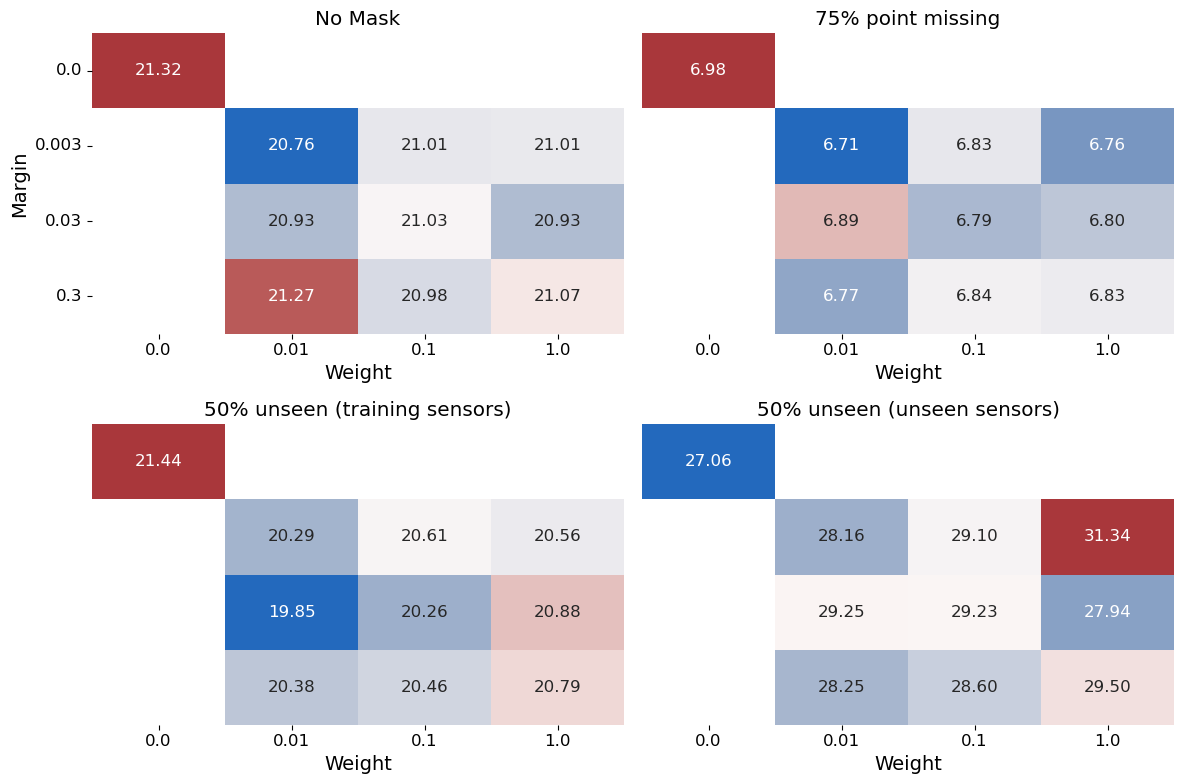

In [47]:
runs.groupby(['mask_name', 'dsn_div_weight', 'dsn_div_margin']).mean()

import matplotlib.pyplot as plt 
import seaborn as sns


fig = plt.figure(figsize=(12,8))

mask_dictionary = {
    'no_mask': 'No Mask',
    'point_missing_075': '75% point missing',
    'tr_drop_050_av': '50% unseen (training sensors)',
    'tr_drop_050_unav': '50% unseen (unseen sensors)',
    'tr_drop_075': '75% unseen sensors',
}

mask_i = 0

for mask in ['no_mask', 'point_missing_075', 'tr_drop_050_av', 'tr_drop_050_unav']:
    filter_name = mask if not mask.startswith('tr_drop_') else 'tr_drop_050'
    mask_data = runs[runs.mask_name == filter_name]
    ax = fig.add_subplot(2,2, mask_i + 1)
    value_name = 'test_avg_mae'
    if mask == 'tr_drop_050_av':
        value_name = 'test_available_sensors_avg_mae'
    elif mask == 'tr_drop_050_unav':
        value_name = 'test_unavailable_sensors_avg_mae'
    sns.heatmap(mask_data.pivot_table(index='dsn_div_margin', columns='dsn_div_weight', values=value_name), annot=True, fmt=".2f", cmap='vlag', ax=ax, cbar = mask_i == 4)
    if mask_i == 0:
        ax.set_ylabel('Margin', fontsize=14)
    else:
        ax.set_ylabel(None)
        ax.set_yticks([])
        
    ax.set_xlabel('Weight', fontsize=14)
    
    mask_i += 1
    ax.set_title(mask_dictionary[mask])
    
    ax.tick_params(axis='y', labelrotation=0)
    
plt.tight_layout()
plt.savefig('img/ablation_repulsion_loss.png', dpi=300, bbox_inches='tight')

## Naive baseline


In [1]:
import torch

import src.utils.dataloader as sud
import pandas as pd
import numpy as np
import os

ptr = np.load(os.path.join('data/sd', '2019', 'his.npz'), allow_pickle=True)

dataset_info = sud.get_dataset_info('SD')



In [2]:
adj = sud.load_adj_from_numpy(dataset_info[1])
adj = 1- adj


In [3]:
from sklearn.neighbors import KNeighborsRegressor

In [4]:
sensor_mask = torch.load('data/masks/sd/tr_drop_025/mask_00/train_mask.pt')[0, :]

In [5]:
masked_data = ptr['data'][..., 0].T[sensor_mask]
masked_adj = adj[sensor_mask][:, sensor_mask]

In [11]:
regressor = KNeighborsRegressor(n_neighbors=6, weights='uniform',metric= 'precomputed')

regressor.fit(masked_adj, masked_data)



KNeighborsRegressor(metric='precomputed', n_neighbors=6)

In [12]:
unseen_prediction = (regressor.predict(adj[~sensor_mask][:, sensor_mask]) * ptr['std']) + ptr['mean']

In [13]:
unseen_gt_data = (ptr['data'][..., 0].T[~sensor_mask] * ptr['std']) + ptr['mean']



In [14]:
np.abs(unseen_prediction - unseen_gt_data).mean()

71.61960021257183

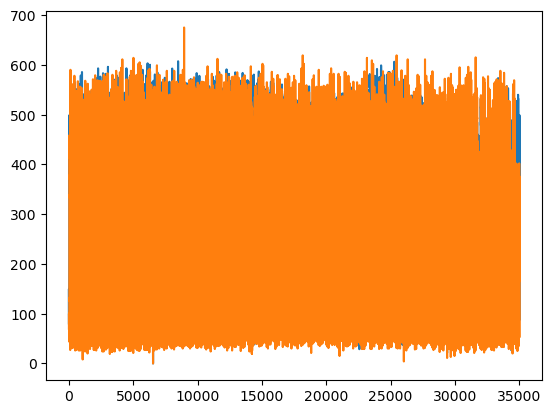

In [16]:
import matplotlib. pyplot as plt

plt.plot(unseen_prediction[50])
plt.plot(unseen_gt_data[50])